# Refactor of H5 Processing

In [2]:
%load_ext autoreload
%autoreload 2

import sys, logging, importlib

# Ensure your scripts dir is importable
sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/scripts/postprocessing")

# 1) Set global logging and quiet noisy libs
logging.basicConfig(
    level=logging.DEBUG,
    format="%(asctime)s - %(levelname)s - %(name)s - %(message)s",
    force=True,
)
for noisy in ["uproot", "fsspec", "s3fs", "urllib3", "numexpr", "matplotlib"]:
    logging.getLogger(noisy).setLevel(logging.WARNING)

# 2) Turn up only your modules to DEBUG (others inherit WARNING from above)
for name in [
    "convert_all",
    "convert_particles",
    "convert_digihits",
    "convert_tracks",
    "utils",
    "utils.track_utils",
    "utils.driver",
    "utils.path_utils",
]:
    logging.getLogger(name).setLevel(logging.DEBUG)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot
import sys
import seaborn as sns
from tqdm import tqdm
import networkx as nx
import matplotlib.cm as cm
import h5py
import logging
import awkward as ak
import uproot

import atlasify as atl
from particle import Particle
atl.ATLAS = "ColliderML"

sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/OtherLibraries/pyedm4hep")
from pyedm4hep import EDM4hepEvent, EDM4hepEventBatch

from pathlib import Path
import logging

# Reuse postprocessing helpers
sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/scripts/postprocessing")
from convert_particles import build_particles_df_with_parents_and_vertex, write_particles_with_selection
from convert_digihits import process_event_for_digihits, write_digihits_with_selection
from utils.path_utils import get_run_paths, make_dir
from utils.track_utils import load_root_file, load_track_summary, create_particle_barcode_map

from convert_all import convert_all


2025-10-14 06:24:38,433 - DEBUG - h5py._conv - Creating converter from 7 to 5
2025-10-14 06:24:38,435 - DEBUG - h5py._conv - Creating converter from 5 to 7
2025-10-14 06:24:38,435 - DEBUG - h5py._conv - Creating converter from 7 to 5
2025-10-14 06:24:38,435 - DEBUG - h5py._conv - Creating converter from 5 to 7


## EDM4Hep Event Batch Testing

In [6]:
local_events = [0, 10]
edm_input_file = "/global/cfs/cdirs/m4958/data/ColliderML/simulation/hard_scatter/ttbar/v1/runs/0/edm4hep.root"
event = EDM4hepEventBatch(edm_input_file, events=local_events)

2025-10-14 06:25:53,460 - DEBUG - pyedm4hep.event_batch - EDM4hepEventBatch init: file=/global/cfs/cdirs/m4958/data/ColliderML/simulation/hard_scatter/ttbar/v1/runs/0/edm4hep.root, events=[0, 10], full_load=False


In [7]:
print(f"""
Number of calo hits: {len(event.get_calo_hits_df())}
Number of particles: {len(event.get_particles_df())}
Number of tracker hits: {len(event.get_tracker_hits_df())}
""")

2025-10-14 06:25:55,095 - DEBUG - pyedm4hep.event_batch - _load_calo_hits: start=0, stop=10
2025-10-14 06:25:55,097 - DEBUG - asyncio - Using selector: EpollSelector
2025-10-14 06:25:55,205 - DEBUG - pyedm4hep.event_batch - calo ECalBarrelCollection: rows=147256 cols=['event_id', 'subentry', 'cellID', 'energy', 'x', 'y', 'z', 'contribution_begin', 'contribution_end', 'detector']
2025-10-14 06:25:55,298 - DEBUG - pyedm4hep.event_batch - calo ECalEndcapCollection: rows=158196 cols=['event_id', 'subentry', 'cellID', 'energy', 'x', 'y', 'z', 'contribution_begin', 'contribution_end', 'detector']
2025-10-14 06:25:55,353 - DEBUG - pyedm4hep.event_batch - calo HCalBarrelCollection: rows=57707 cols=['event_id', 'subentry', 'cellID', 'energy', 'x', 'y', 'z', 'contribution_begin', 'contribution_end', 'detector']
2025-10-14 06:25:55,422 - DEBUG - pyedm4hep.event_batch - calo HCalEndcapCollection: rows=129389 cols=['event_id', 'subentry', 'cellID', 'energy', 'x', 'y', 'z', 'contribution_begin', 'co


Number of calo hits: 492548
Number of particles: 48618
Number of tracker hits: 36676



## Combined multi-output conversion (single open per run)

This workflow opens each `edm4hep.root` once per run and produces multiple H5 outputs (truth/particles and reco/tracker_hits) in one pass, reusing preloaded DataFrames to avoid repeated IO.


### Event lists and loading edm4hep events

In [8]:
from convert_all import *
from convert_all import _compute_paths, _prepare_output_dirs
from convert_digihits import *
from convert_tracks import *
from utils.path_utils import *
from utils.track_utils import *
from utils.driver import *
from utils.config import *


In [9]:
# Configurable column selection for H5 outputs
particles_columns_keep = [
    "particle_id", "pdg_id", "mass", "energy", "charge",
    "vx", "vy", "vz", "time", "px", "py", "pz",
    "num_tracker_hits", "num_calo_hits", "vertex_primary", "parent_id",
]
digihits_columns_keep = [
    "x", "y", "z", "time", "particle_id",
    "true_x", "true_y", "true_z",
    "volume_id", "layer_id", "surface_id",
    "cell_id", "detector", "event_id",
]

tracks_columns_keep = [
    "event_id", "majority_particle_id", "d0", "z0", "phi", "theta", "qop"
]


In [14]:
# Config for this combined test (aligns with your production YAMLs)
campaign = "hard_scatter"
dataset = "ttbar"
version = "v1"

base_root = Path("/global/cfs/cdirs/m4958/data/ColliderML/simulation")
output_base_dir = Path("./h5_hardscatter_testing/v1")  # unified root like scripts

config = {
    "chunk_size": 10,
    "run_size": 128,
    "max_chunks": 1,
    "campaign": "hard_scatter",
    "dataset": "ttbar",
    "version": "v1",
    "common": {
        "output_base_dir": base_root,
        "input_base_dir": base_root,
    },
    "objects": ["tracker_hits", "particles", "tracks"],
    "particles_columns_keep": particles_columns_keep,
    "digihits_columns_keep": digihits_columns_keep,
    "tracks_columns_keep": tracks_columns_keep,
    "min_tracker_hits": 1,
    "h5_output_dir": output_base_dir,
}


In [15]:
input_base_dir, output_base_dir, dataset_base, dataset_name_dot = _compute_paths(config)
particles_out_dir, trkhits_out_dir, tracks_out_dir = _prepare_output_dirs(output_base_dir, dataset_base)

In [16]:
particles_frames: list[pd.DataFrame] = []
digihits_frames: list[pd.DataFrame] = []
tracks_frames: list[pd.DataFrame] = []
seen_pairs_tracks: set[tuple[int, int]] = set()
seen_pairs_particles: set[tuple[int, int]] = set()
seen_pairs_hits: set[tuple[int, int]] = set()

In [17]:
run_size = 128
chunk_size = 10
run_dirs = get_run_paths(input_base_dir)
num_runs = len(run_dirs)
num_events = num_runs * run_size

In [18]:
chunk_index = 0

In [19]:
start_event = chunk_index * chunk_size
end_event = min(num_events, start_event + chunk_size) - 1
start_run = start_event // run_size
start_local = start_event % run_size
end_run = end_event // run_size
end_local = end_event % run_size

In [20]:
print(f"Start event: {start_event}, End event: {end_event}, Start run: {start_run}, End run: {end_run}, Start local: {start_local}, End local: {end_local}")

Start event: 0, End event: 9, Start run: 0, End run: 0, Start local: 0, End local: 9


In [21]:
abs_run = start_run
run_dir = run_dirs[abs_run]

In [22]:
local_events = local_events_for_run(
        start_run=start_run,
        start_local=start_local,
        end_run=end_run,
        end_local=end_local,
        abs_run=abs_run,
        run_size=run_size,
    )

In [23]:
local_events

(0, 10)

In [24]:
edm4hep_path = run_dir / "edm4hep.root"
batch = EDM4hepEventBatch(str(edm4hep_path), events=local_events)

2025-10-14 06:28:57,896 - DEBUG - pyedm4hep.event_batch - EDM4hepEventBatch init: file=/global/cfs/cdirs/m4958/data/ColliderML/simulation/hard_scatter/ttbar/v1/runs/0/edm4hep.root, events=(0, 10), full_load=False


In [25]:
%%time
particles_root_path = Path(run_dir) / "particles.root"
included_columns = [
                        "event_id",
                        "vx",
                        "vy",
                        "vz",
                        "px",
                        "py",
                        "pz",
                        "vertex_primary",
                    ]
digi_particles_df_run = load_root_file(str(particles_root_path), included_columns=included_columns, events=local_events)
digi_particles_df_run

CPU times: user 166 ms, sys: 256 ms, total: 422 ms
Wall time: 417 ms


event_id          vx            vy           vz         px  \
entry subentry                                                               
0     0                0    0.000000  0.000000e+00     0.000000  12.111033   
      1                0    0.000000  0.000000e+00     0.000000  43.898525   
      2                0    0.000000  0.000000e+00     0.000000  32.571106   
      3                0    0.000000  0.000000e+00     0.000000   1.361503   
      4                0    0.000000  0.000000e+00     0.000000   0.518549   
...                  ...         ...           ...          ...        ...   
9     6036             9  429.192627 -9.660960e+01  3200.327393   0.108181   
      6037             9  443.960388 -1.065876e+03  3200.535645   0.025950   
      6038             9   -0.000001  1.761500e-07     0.000579  -1.329381   
      6039             9    0.000003  3.975806e-08     0.004405  -0.005715   
      6040             9    0.000003  3.975806e-08     0.004405   0.049053   

                       py          pz  vertex_primary  
entry subentry                                         
0     0         48.026073   72.044685               1  
      1        -20.764874  106.692947               1  
      2         34.368645  -20.173618               1  
      3          0.841040   -0.745837               1  
      4          0.328355   -0.336921               1  
...                   ...         ...             ...  
9     6036      -0.030273    0.286036               1  
      6037      -0.071354    0.071238               1  
      6038       0.198973  653.670349               1  
      6039      -0.053277   15.257035               1  
      6040       0.053916   55.556877               1  

[44851 rows x 8 columns]

In [26]:
digi_particles_df_run.event_id.unique()

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint32)

In [28]:
batch._ensure_loaded("tracker_hits")
batch._ensure_loaded("calo_hits")
parts_all = batch.get_particles_df()
parents_all = batch.get_parents_df()

2025-10-14 06:29:28,149 - DEBUG - pyedm4hep.event_batch - _load_calo_hits: start=0, stop=10
2025-10-14 06:29:28,227 - DEBUG - pyedm4hep.event_batch - calo ECalBarrelCollection: rows=147256 cols=['event_id', 'subentry', 'cellID', 'energy', 'x', 'y', 'z', 'contribution_begin', 'contribution_end', 'detector']
2025-10-14 06:29:28,320 - DEBUG - pyedm4hep.event_batch - calo ECalEndcapCollection: rows=158196 cols=['event_id', 'subentry', 'cellID', 'energy', 'x', 'y', 'z', 'contribution_begin', 'contribution_end', 'detector']
2025-10-14 06:29:28,378 - DEBUG - pyedm4hep.event_batch - calo HCalBarrelCollection: rows=57707 cols=['event_id', 'subentry', 'cellID', 'energy', 'x', 'y', 'z', 'contribution_begin', 'contribution_end', 'detector']
2025-10-14 06:29:28,451 - DEBUG - pyedm4hep.event_batch - calo HCalEndcapCollection: rows=129389 cols=['event_id', 'subentry', 'cellID', 'energy', 'x', 'y', 'z', 'contribution_begin', 'contribution_end', 'detector']
2025-10-14 06:29:28,474 - DEBUG - pyedm4hep.e

Augmenting particle hit counts with tracker hits


In [29]:
parts_all

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,pz,parents_begin,parents_end,vr,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
0,0,0,2212,0,1.000000,0.000000,0.938270,0.000000,0.000000,0.000000,...,6999.999937,0,0,0.000000,7000.000000,6999.061730,0,False,0,0
1,0,1,21,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1210.616972,0,1,0.000000,1210.616972,1210.616972,1,False,0,0
2,0,2,2,0,0.666667,0.000000,0.330000,0.000000,0.000000,0.000000,...,3436.204368,1,2,0.000000,3436.204384,3435.874384,2,False,0,0
3,0,3,2103,0,0.333333,0.000000,0.771330,0.000000,0.000000,0.000000,...,2353.178474,2,3,0.000000,2353.178600,2352.407270,3,False,0,0
4,0,4,2212,0,1.000000,0.000000,0.938270,0.000000,0.000000,0.000000,...,-6999.999937,3,3,0.000000,7000.000000,6999.061730,4,False,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48613,9,6680,22,1224736768,0.000000,0.000264,0.000000,0.000551,-0.000136,-0.079079,...,-0.368540,10186,10187,0.000568,0.368726,0.368726,6680,True,0,0
48614,9,6681,11,1107296256,-1.000000,6.518255,0.000511,58.881462,19.764014,-1953.136306,...,-0.244566,10187,10188,62.109925,0.244666,0.244155,6681,True,0,0
48615,9,6682,-11,1107296256,1.000000,6.518255,0.000511,58.881462,19.764014,-1953.136306,...,-0.123987,10188,10189,62.109925,0.124060,0.123549,6682,True,0,0
48616,9,6683,22,1107296256,0.000000,0.000117,0.000000,0.000104,0.000243,-0.035186,...,-41.824142,10189,10190,0.000264,41.825116,41.825116,6683,True,0,0


In [30]:
digi_particles_df_run

event_id          vx            vy           vz         px  \
entry subentry                                                               
0     0                0    0.000000  0.000000e+00     0.000000  12.111033   
      1                0    0.000000  0.000000e+00     0.000000  43.898525   
      2                0    0.000000  0.000000e+00     0.000000  32.571106   
      3                0    0.000000  0.000000e+00     0.000000   1.361503   
      4                0    0.000000  0.000000e+00     0.000000   0.518549   
...                  ...         ...           ...          ...        ...   
9     6036             9  429.192627 -9.660960e+01  3200.327393   0.108181   
      6037             9  443.960388 -1.065876e+03  3200.535645   0.025950   
      6038             9   -0.000001  1.761500e-07     0.000579  -1.329381   
      6039             9    0.000003  3.975806e-08     0.004405  -0.005715   
      6040             9    0.000003  3.975806e-08     0.004405   0.049053   

                       py          pz  vertex_primary  
entry subentry                                         
0     0         48.026073   72.044685               1  
      1        -20.764874  106.692947               1  
      2         34.368645  -20.173618               1  
      3          0.841040   -0.745837               1  
      4          0.328355   -0.336921               1  
...                   ...         ...             ...  
9     6036      -0.030273    0.286036               1  
      6037      -0.071354    0.071238               1  
      6038       0.198973  653.670349               1  
      6039      -0.053277   15.257035               1  
      6040       0.053916   55.556877               1  

[44851 rows x 8 columns]

In [34]:
particles_event = parts_all[parts_all.event_id == 0]
digi_particles_event = digi_particles_df_run[digi_particles_df_run.event_id == 0]

In [35]:
particles_event.sort_values(by=["vx", "vy", "vz", "px", "py", "pz"])

,event_id,subentry,PDG,simulatorStatus,charge,time,mass,vx,vy,vz,...,pz,parents_begin,parents_end,vr,energy,kinetic_energy,particle_id,created_in_simulation,num_tracker_hits,num_calo_hits
556,0,556,-211,1157627904,-1.0,8.670385,0.139570,-1508.117831,-1434.450157,-1470.902211,...,-0.575649,1558,1559,2081.361728,1.225328,1.085758,556,True,0,0
576,0,576,-11,1426063360,1.0,7.301447,0.000511,-1437.882210,93.596558,-1619.359462,...,-0.122450,1578,1579,1440.925247,0.135077,0.134566,576,True,0,0
575,0,575,-11,1426063360,1.0,7.097603,0.000511,-1412.925273,100.026338,-1563.940595,...,-0.100547,1577,1578,1416.461469,0.111461,0.110950,575,True,0,0
574,0,574,-11,1426063360,1.0,7.044624,0.000511,-1406.442615,101.920256,-1549.573607,...,-0.445712,1576,1577,1410.130692,0.498879,0.498368,574,True,0,0
573,0,573,11,1426063360,-1.0,7.044624,0.000511,-1406.442615,101.920256,-1549.573607,...,-0.145403,1575,1576,1410.130692,0.163922,0.163411,573,True,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2143,0,2143,11,1426063360,-1.0,6.715137,0.000511,1312.936983,1174.572389,-952.417998,...,-0.086157,3145,3146,1761.653717,0.146105,0.145594,2143,True,0,0
2139,0,2139,2212,1157627904,1.0,6.802287,0.938272,1322.386358,1175.592956,-926.434097,...,0.195820,3141,3142,1769.385339,1.127625,0.189353,2139,True,0,0
2142,0,2142,11,1426063360,-1.0,7.058209,0.000511,1353.866816,1244.727362,-1015.517572,...,-0.072784,3144,3145,1839.103467,0.119015,0.118504,2142,True,0,0
2075,0,2075,2212,1157627904,1.0,5.461786,0.938272,1452.102868,302.284829,-570.480950,...,0.405624,3077,3078,1483.232570,1.043336,0.105064,2075,True,0,0


In [36]:
digi_particles_event.sort_values(by=["vx", "vy", "vz", "px", "py", "pz"])

event_id           vx           vy           vz        px  \
entry subentry                                                              
0     1890             0 -1508.117798 -1434.450195 -1470.902222 -0.725961   
      1880             0 -1437.882202    93.596558 -1619.359497 -0.055012   
      1879             0 -1412.925293   100.026337 -1563.940552 -0.043526   
      1865             0 -1406.442627   101.920258 -1549.573608 -0.216051   
      1864             0 -1406.442627   101.920258 -1549.573608 -0.072529   
...                  ...          ...          ...          ...       ...   
      933              0  1312.937012  1174.572388  -952.417969  0.060874   
      935              0  1322.386353  1175.592896  -926.434082  0.364374   
      932              0  1353.866821  1244.727417 -1015.517578  0.047285   
      956              0  1452.102905   302.284821  -570.480957 -0.165690   
      947              0  2082.849854  1500.000977 -1407.322388  0.106238   

                      py        pz  vertex_primary  
entry subentry                                      
0     1890     -0.789657 -0.575649               1  
      1880     -0.015005 -0.122450               1  
      1879     -0.020471 -0.100547               1  
      1865     -0.059528 -0.445712               1  
      1864     -0.021624 -0.145403               1  
...                  ...       ...             ...  
      933       0.101083 -0.086157               1  
      935       0.469115  0.195820               1  
      932       0.081430 -0.072784               1  
      956       0.127322  0.405624               1  
      947       0.082666 -0.080558               1  

[2035 rows x 8 columns]

In [37]:
print(f"""
Number of particles: {len(particles_event)}
Number of particles with at least 1 tracker hit: {len(particles_event[particles_event.num_tracker_hits > 0])}
Number of particles created in generator: {len(particles_event[~particles_event.created_in_simulation])}
Number of particles with at least 1 tracker hit OR created in generator: {len(particles_event[(particles_event.num_tracker_hits > 0) | (~particles_event.created_in_simulation)])}
""")


Number of particles: 2224
Number of particles with at least 1 tracker hit: 439
Number of particles created in generator: 394
Number of particles with at least 1 tracker hit OR created in generator: 766



In [38]:
min_particle_energy = None
min_tracker_hits = 1
df_run = build_particles_df_with_parents_and_vertex(
                batch,
                str(edm4hep_path),
                digi_particles_df_run,
                local_events=local_events,
                min_particle_energy=min_particle_energy,
                min_tracker_hits=min_tracker_hits,
            )
global_event_nums = df_run["event_id"] + abs_run * run_size
df_run["event_id"] = global_event_nums
particles_frames.append(df_run)

2025-10-14 06:31:44,325 - DEBUG - convert_particles - Building particles DataFrame with parents and vertex info for 2 events
2025-10-14 06:31:44,327 - DEBUG - convert_particles - Particles DataFrame shape: (48618, 22), with columns Index(['event_id', 'subentry', 'PDG', 'simulatorStatus', 'charge', 'time',
       'mass', 'vx', 'vy', 'vz', 'px', 'py', 'pz', 'parents_begin',
       'parents_end', 'vr', 'energy', 'kinetic_energy', 'particle_id',
       'created_in_simulation', 'num_tracker_hits', 'num_calo_hits'],
      dtype='object'), and unique events 10
2025-10-14 06:31:44,328 - DEBUG - convert_particles - Parents DataFrame shape: (63288, 4), with columns Index(['event_id', 'subentry', 'particle_id', 'collectionID'], dtype='object'), and unique events 10
2025-10-14 06:31:44,331 - DEBUG - convert_particles - Particles root DataFrame shape: (44851, 8), with columns Index(['event_id', 'vx', 'vy', 'vz', 'px', 'py', 'pz', 'vertex_primary'], dtype='object'), and unique events 10
2025-10-14 0

Particles event:  0 (2224, 22) (2035, 8)
Particles event:  1 (2725, 22) (2564, 8)
Particles event:  2 (3190, 22) (2998, 8)
Particles event:  3 (2146, 22) (1850, 8)
Particles event:  4 (4391, 22) (4118, 8)
Particles event:  5 (5561, 22) (4904, 8)
Particles event:  6 (6994, 22) (6483, 8)
Particles event:  7 (8665, 22) (8287, 8)
Particles event:  8 (6037, 22) (5571, 8)
Particles event:  9 (6685, 22) (6041, 8)


In [40]:
df_run

,particle_id,pdg_id,mass,energy,charge,vx,vy,vz,time,px,py,pz,num_tracker_hits,num_calo_hits,vertex_primary,parent_id,event_id
0,76,213,0.738762,2491.611858,1.0,0.000000,0.000000,0.000000,0.000000,0.033283,-0.117263,2491.611816,0,0,1,9.0,0
1,77,-211,0.139570,489.566210,-1.0,0.000000,0.000000,0.000000,0.000000,-0.342658,0.317618,489.565979,0,0,1,9.0,0
2,78,211,0.139570,199.210307,1.0,0.000000,0.000000,0.000000,0.000000,0.113722,-0.172773,199.210144,0,0,1,9.0,0
3,79,113,0.701754,140.076040,0.0,0.000000,0.000000,0.000000,0.000000,0.344190,0.453400,140.073120,0,0,1,9.0,0
4,80,111,0.134980,50.874247,0.0,0.000000,0.000000,0.000000,0.000000,-0.084311,-0.564865,50.870861,0,0,1,9.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10894,6657,11,0.000511,0.003069,-1.0,174.407349,-762.927673,-1876.461548,6952.824219,0.002318,0.001772,-0.000803,3,0,1,492.0,9
10895,6668,11,0.000511,1.117706,-1.0,23.442141,-24.064728,-197.193253,0.667243,0.129789,-0.133815,-1.102050,11,0,1,6660.0,9
10896,6669,-11,0.000511,0.326179,1.0,23.442141,-24.064728,-197.193253,0.667243,0.039144,-0.039739,-0.321374,9,0,1,6660.0,9
10897,6670,11,0.000511,0.002774,-1.0,-12.718798,-110.886360,-980.260193,3.309390,-0.001632,0.000784,-0.002039,2,0,1,6669.0,9


In [84]:
measurements_path = Path(run_dir) / "measurements.root"
included_columns = [
            "event_nr",
                "volume_id",
                "layer_id",
                "surface_id",
                "extra_id",
                "rec_gx",
                "rec_gy",
                "rec_gz",
                "true_x",
                "true_y",
                "true_z",
            ]
digi_measurements_df_all = load_root_file(str(measurements_path), included_columns=included_columns, events=local_events)

In [86]:
spacepoints_path = Path(run_dir) / "spacepoints.root"
included_columns = [
            'event_id', 'measurement_id', 'geometry_id', 'measurement_id_2', 'geometry_id_2', 'x', 'y', 'z', 'r', 't', 'var_r', 'var_z', 'fake'
            ]
spacepoints_df_all = load_root_file(str(spacepoints_path), included_columns=included_columns, events=local_events)

In [87]:
hits_all = batch.get_tracker_hits_df()

In [90]:
hits_all

,event_id,subentry,cellID,time,x,y,z,detector,particle_id,r,R,phi,theta,eta
0,0,0,61536981452860470,23.228270,-159.489368,-61.638809,368.782149,PixelBarrelReadout,400,170.985968,406.492896,-2.772799,0.434147,1.511636
1,0,1,61344661407279926,23.235228,-157.993789,-61.146887,368.288474,PixelBarrelReadout,400,169.413633,405.385470,-2.772325,0.431141,1.518807
2,0,2,8496909896064550,23.487328,-102.010437,-51.754918,350.356099,PixelBarrelReadout,400,114.388377,368.556776,-2.672083,0.315581,1.838141
3,0,3,64844703271168550,24.177742,39.339970,-107.369686,305.696916,PixelBarrelReadout,400,114.349826,326.383956,-1.219589,0.357949,1.709755
4,0,4,59408863812337718,24.434616,73.272469,-153.556919,290.279500,PixelBarrelReadout,400,170.142828,336.468082,-1.125580,0.530162,1.303906
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36671,9,885,1047972024398,58.945755,787.404988,67.437001,2574.500000,LongStripEndcapReadout,6529,790.287520,2693.066025,0.085436,0.297837,1.896927
36672,9,886,1447404130318,24.701817,60.540491,-852.340010,1274.500000,LongStripEndcapReadout,6552,854.487357,1534.437647,-1.499887,0.590617,1.190060
36673,9,887,1524714590222,24.726156,59.890487,-856.547392,1279.500000,LongStripEndcapReadout,6552,858.638635,1540.902513,-1.500989,0.591047,1.189287
36674,9,888,1249835634718,26.007154,67.356697,-849.458050,1574.375000,LongStripEndcapReadout,6552,852.124347,1790.187851,-1.491668,0.496098,1.373321


In [91]:
digi_measurements_df = digi_measurements_df_all[digi_measurements_df_all.event_id == 0]

In [92]:
spacepoints_df = spacepoints_df_all[spacepoints_df_all.event_id == 0]

In [93]:
spacepoints_df

,event_id,measurement_id,geometry_id,measurement_id_2,geometry_id_2,x,y,z,r,t,var_r,var_z,fake
entry,,,,,,,,,,,,,
0,0,1531,2017612770500956673,1530,2017612770500956417,697.910828,-325.881958,-2990.5,770.245789,NaN,0.004060,7.936318e-35,True
1,0,1526,2017612770500942849,1525,2017612770500942593,-666.165771,363.934509,-2979.5,759.094971,NaN,0.000642,1.167945e-35,True
2,0,1524,2017612770500941825,1523,2017612770500941569,-623.402893,513.568298,-2990.5,807.702637,NaN,0.004025,5.871660e-35,True
3,0,1522,2017612770500938241,1521,2017612770500937985,23.886007,822.813660,-2979.5,823.160278,NaN,0.005951,5.324443e-36,True
4,0,1540,2017612770500978946,1542,2017612770500979202,573.800659,-852.592163,-3025.5,1027.696777,NaN,0.000745,6.233632e-36,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0,2054,2161728508332639234,2053,2161728508332638978,-1037.828125,-40.676636,2620.5,1038.624878,NaN,0.000700,1.512525e-35,True
107,0,2067,2161728645771572993,2068,2161728645771573249,-290.221527,-815.925110,2974.5,866.003662,NaN,0.000723,2.941843e-36,True
108,0,2066,2161728645771572737,2064,2161728645771572481,-380.454132,-728.074402,2990.5,821.485046,NaN,0.006142,3.911592e-35,True


In [94]:
digi_measurements_df

,event_id,volume_id,layer_id,surface_id,extra_id,rec_gx,rec_gy,rec_gz,true_x,true_y,true_z
entry,,,,,,,,,,,
0,0,16,4,7,1,-71.247047,-33.946491,-1515.599976,-71.269562,-33.943825,-1515.599976
1,0,16,4,15,1,59.503036,-59.255550,-1516.800049,59.485455,-59.259113,-1516.800049
2,0,16,4,21,1,10.475000,88.270973,-1515.599976,10.469092,88.252937,-1515.599976
3,0,16,4,43,2,-53.983902,-162.357468,-1523.800049,-53.980293,-162.355682,-1523.800049
4,0,16,4,51,2,95.332870,-83.224663,-1522.599976,95.338730,-83.203011,-1522.599976
...,...,...,...,...,...,...,...,...,...,...,...
2081,0,30,12,153,2,-252.832672,-957.104614,3025.500000,-257.281860,-975.087097,3025.500000
2082,0,30,12,154,2,-253.589325,-957.031311,3020.500000,-259.259521,-976.532593,3020.500000
2083,0,30,12,159,2,69.154701,-988.219177,3004.500000,60.873756,-913.859192,3004.500000


In [95]:
local_event_num = 0

In [96]:
ev_hits = hits_all[hits_all.event_id == local_event_num] if not hits_all.empty else None
ev_meas = (
    digi_measurements_df_all[digi_measurements_df_all.event_id == local_event_num].copy()
    if "event_id" in getattr(digi_measurements_df_all, "columns", [])
    else digi_measurements_df_all.copy()
)

In [97]:
ev_meas.sort_values(by=["true_x", "true_y", "true_z"])

,event_id,volume_id,layer_id,surface_id,extra_id,rec_gx,rec_gy,rec_gz,true_x,true_y,true_z
entry,,,,,,,,,,,
1536,0,28,2,132,2,-989.746277,-12.684962,-3009.500000,-1067.502075,-14.249893,-3009.500000
1535,0,28,2,131,2,-990.288757,-14.434612,-3004.500000,-1065.891479,-12.892500,-3004.500000
2019,0,30,8,131,2,-988.793823,-60.300438,2275.500000,-1050.920654,-61.578712,2275.500000
2020,0,30,8,132,2,-991.268677,-63.424812,2270.500000,-1048.667358,-62.320236,2270.500000
1537,0,28,2,133,2,-973.525452,-181.865814,-3025.500000,-1039.932617,-191.951172,-3025.442871
...,...,...,...,...,...,...,...,...,...,...,...
1963,0,29,4,3230,0,1001.942627,-187.822769,-325.500000,1001.979980,-187.825607,-319.636383
1890,0,29,4,535,0,1004.010498,176.725540,-650.312195,1004.010437,176.739960,-650.295410
1891,0,29,4,536,0,1010.676880,168.786285,-651.000000,1010.676697,168.810043,-656.548462


In [98]:
ev_hits.sort_values(by=["x", "y", "z"])

,event_id,subentry,cellID,time,x,y,z,detector,particle_id,r,R,phi,theta,eta
31574,0,58,365073367389,10.830770,-1067.502126,-14.249893,-3009.500000,LongStripEndcapReadout,2054,1067.597231,3193.251336,-3.128245,2.800699,-1.759582
31573,0,57,412316959069,10.812613,-1065.891539,-12.892500,-3004.500000,LongStripEndcapReadout,2054,1065.969506,3187.994862,-3.129498,2.800656,-1.759453
31648,0,132,1726576951614,8.801469,-1050.920705,-61.578714,2275.500000,LongStripEndcapReadout,88,1052.723262,2507.214892,-3.083065,0.433310,1.513628
31647,0,131,1816772313406,8.782122,-1048.667304,-62.320235,2270.500000,LongStripEndcapReadout,88,1050.517456,2501.750822,-3.082234,0.433349,1.513535
31546,0,30,16067472757085,469.933624,-1039.932653,-191.951167,-3025.442904,LongStripEndcapReadout,717,1057.499491,3204.935247,-2.959067,2.805332,-1.773530
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26929,0,215,87140608724508,87.354103,1001.979977,-187.825600,-319.636389,LongStripBarrelReadout,1308,1019.432357,1068.367798,-0.185304,1.874632,-0.308621
26972,0,258,493921501724,7.383154,1004.010417,176.739957,-650.295420,LongStripBarrelReadout,2127,1019.447855,1209.197281,0.174249,2.138611,-0.601043
26973,0,259,71987487303795228,7.457931,1010.676724,168.810037,-656.548460,LongStripBarrelReadout,2127,1024.677642,1216.971713,0.165499,2.140632,-0.603441
26967,0,253,71706738160324124,108.173752,1015.126616,-124.516888,187.844404,LongStripBarrelReadout,2118,1022.734815,1039.842306,-0.122052,1.389152,0.182651


In [101]:
evs_for_run = []
digihits_frames = []
seen_pairs_hits = set()
for local_event_num in range(local_events[0], local_events[1]):
    global_event_num = abs_run * run_size + local_event_num
    ev_hits = hits_all[hits_all.event_id == local_event_num] if not hits_all.empty else None
    ev_meas = (
        digi_measurements_df_all[digi_measurements_df_all.event_id == local_event_num].copy()
        if "event_id" in getattr(digi_measurements_df_all, "columns", [])
        else digi_measurements_df_all.copy()
    )
    ev_df = process_event_for_digihits(global_event_num, local_event_num, ev_meas, ev_hits)
    if not ev_df.empty:
        pair = (abs_run, local_event_num)
        if pair in seen_pairs_hits:
            logger.error(
                f"Overlap detected for tracker_hits on (run,local_event)=({abs_run},{local_event_num})"
            )
        seen_pairs_hits.add(pair)
        digihits_frames.append(ev_df)
        evs_for_run.append(ev_df)
if evs_for_run:
    digihits_run_df = pd.concat(evs_for_run, ignore_index=True)

2025-10-14 07:18:57,288 - DEBUG - convert_digihits - Merged columns: Index(['x', 'y', 'z', 'volume_id', 'layer_id', 'surface_id', 'true_x',
       'true_y', 'true_z', 'time', 'particle_id', 'cell_id', 'detector'],
      dtype='object')
2025-10-14 07:18:57,289 - DEBUG - root - Event 0: merged measurements 2086 -> 2086 in 0.010s
2025-10-14 07:18:57,299 - DEBUG - convert_digihits - Merged columns: Index(['x', 'y', 'z', 'volume_id', 'layer_id', 'surface_id', 'true_x',
       'true_y', 'true_z', 'time', 'particle_id', 'cell_id', 'detector'],
      dtype='object')
2025-10-14 07:18:57,300 - DEBUG - root - Event 1: merged measurements 1621 -> 1621 in 0.009s
2025-10-14 07:18:57,311 - DEBUG - convert_digihits - Merged columns: Index(['x', 'y', 'z', 'volume_id', 'layer_id', 'surface_id', 'true_x',
       'true_y', 'true_z', 'time', 'particle_id', 'cell_id', 'detector'],
      dtype='object')
2025-10-14 07:18:57,311 - DEBUG - root - Event 2: merged measurements 2787 -> 2787 in 0.010s
2025-10-14 07

2025-10-14 07:18:57,334 - DEBUG - convert_digihits - Merged columns: Index(['x', 'y', 'z', 'volume_id', 'layer_id', 'surface_id', 'true_x',
       'true_y', 'true_z', 'time', 'particle_id', 'cell_id', 'detector'],
      dtype='object')
2025-10-14 07:18:57,334 - DEBUG - root - Event 4: merged measurements 3926 -> 3926 in 0.010s
2025-10-14 07:18:57,347 - DEBUG - convert_digihits - Merged columns: Index(['x', 'y', 'z', 'volume_id', 'layer_id', 'surface_id', 'true_x',
       'true_y', 'true_z', 'time', 'particle_id', 'cell_id', 'detector'],
      dtype='object')
2025-10-14 07:18:57,347 - DEBUG - root - Event 5: merged measurements 5463 -> 5463 in 0.011s
2025-10-14 07:18:57,360 - DEBUG - convert_digihits - Merged columns: Index(['x', 'y', 'z', 'volume_id', 'layer_id', 'surface_id', 'true_x',
       'true_y', 'true_z', 'time', 'particle_id', 'cell_id', 'detector'],
      dtype='object')
2025-10-14 07:18:57,360 - DEBUG - root - Event 6: merged measurements 6334 -> 6334 in 0.011s
2025-10-14 07

In [102]:
digihits_run_df

,x,y,z,volume_id,layer_id,surface_id,true_x,true_y,true_z,time,particle_id,cell_id,detector,event_id
0,-71.247047,-33.946491,-1515.599976,16,4,7,-71.269562,-33.943825,-1515.599976,5.067120,276,536870926439,1,0
1,59.503036,-59.255550,-1516.800049,16,4,15,59.485455,-59.259113,-1516.800049,5.070502,280,17579301164135,1,0
2,10.475000,88.270973,-1515.599976,16,4,21,10.469092,88.252937,-1515.599976,5.078973,281,897648171111,1,0
3,-53.983902,-162.357468,-1523.800049,16,4,43,-53.980293,-162.355682,-1523.800049,15.764151,505,17179869209959,1,0
4,95.332870,-83.224663,-1522.599976,16,4,51,95.338730,-83.203011,-1522.599976,5.120812,331,210453430631,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36670,581.583191,800.943054,3009.500000,30,12,188,571.583618,787.337280,3009.500000,11.151474,5130,16840567845214,5,9
36671,455.531952,879.111450,3025.500000,30,12,189,455.609589,879.305420,3025.500000,12.496464,4968,1292785189214,5,9
36672,465.419586,875.241516,3020.500000,30,12,190,460.525452,867.079102,3020.500000,12.449465,4968,987843559774,5,9
36673,420.708252,896.316223,3004.500000,30,12,191,450.809998,965.018433,3004.500000,10.677485,283,1309965062494,5,9


In [103]:
this_event_digihits = digihits_run_df[digihits_run_df.event_id == 0]
duplicates = this_event_digihits[this_event_digihits.duplicated(subset=["true_x", "true_y", "true_z"], keep=False)]
duplicates

,x,y,z,volume_id,layer_id,surface_id,true_x,true_y,true_z,time,particle_id,cell_id,detector,event_id


In [118]:
this_event_digihits

,x,y,z,volume_id,layer_id,surface_id,true_x,true_y,true_z,time,particle_id,cell_id,detector,event_id,r
0,-71.247047,-33.946491,-1515.599976,16,4,7,-71.269562,-33.943825,-1515.599976,5.067120,276,536870926439,1,0,78.940064
1,59.503036,-59.255550,-1516.800049,16,4,15,59.485455,-59.259113,-1516.800049,5.070502,280,17579301164135,1,0,83.965242
2,10.475000,88.270973,-1515.599976,16,4,21,10.469092,88.252937,-1515.599976,5.078973,281,897648171111,1,0,88.871721
3,-53.983902,-162.357468,-1523.800049,16,4,43,-53.980293,-162.355682,-1523.800049,15.764151,505,17179869209959,1,0,171.094242
4,95.332870,-83.224663,-1522.599976,16,4,51,95.338730,-83.203011,-1522.599976,5.120812,331,210453430631,1,0,126.539379
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2081,-252.832672,-957.104614,3025.500000,30,12,153,-257.281860,-975.087097,3025.500000,12.086170,1088,98784387422,5,0,1008.458627
2082,-253.589325,-957.031311,3020.500000,30,12,154,-259.259521,-976.532593,3020.500000,12.067312,1088,77310599518,5,0,1010.362016
2083,69.154701,-988.219177,3004.500000,30,12,159,60.873756,-913.859192,3004.500000,10.934148,1530,1730871972190,5,0,915.884401
2084,72.868668,-990.099060,3009.500000,30,12,160,61.670364,-916.778748,3009.500000,10.954133,1530,1632088772958,5,0,918.850644


/tmp/ipykernel_350165/3312524477.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  this_event_digihits['r'] = np.sqrt(this_event_digihits['true_x']**2 + this_event_digihits['true_y']**2)


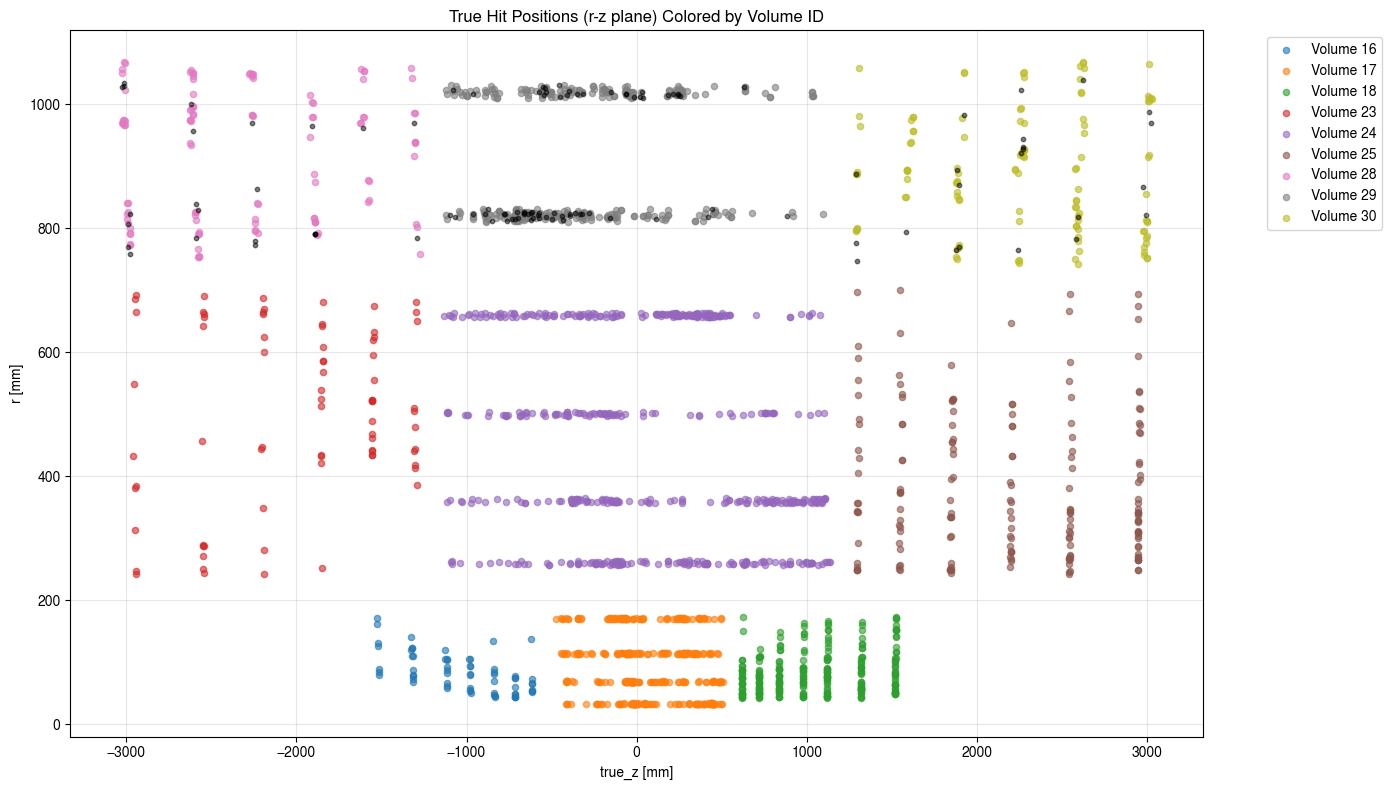

In [122]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate r from true_x and true_y
this_event_digihits['r'] = np.sqrt(this_event_digihits['true_x']**2 + this_event_digihits['true_y']**2)

# Create 2D scatter plot of r vs z colored by volume_id
fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111)

# Get unique volume_ids for color mapping
volume_ids = this_event_digihits['volume_id'].unique()
colors = plt.cm.tab10(range(len(volume_ids)))

# Plot each volume_id with a different color
for i, vol_id in enumerate(sorted(volume_ids)):
    vol_data = this_event_digihits[this_event_digihits['volume_id'] == vol_id]
    ax.scatter(vol_data['true_z'], vol_data['r'], 
               c=[colors[i]], label=f'Volume {vol_id}', s=20, alpha=0.6)

ax.scatter(spacepoints_df.z, spacepoints_df.r, c="black", s=10, alpha=0.5)

ax.set_xlabel('true_z [mm]')
ax.set_ylabel('r [mm]')
ax.set_title('True Hit Positions (r-z plane) Colored by Volume ID')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



In [66]:
spacepoints_df

,event_id,measurement_id,geometry_id,measurement_id_2,geometry_id_2,x,y,z,r,t,var_r,var_z,fake
entry,,,,,,,,,,,,,
0,0,1531,2017612770500956673,1530,2017612770500956417,697.910828,-325.881958,-2990.5,770.245789,NaN,0.004060,7.936318e-35,True
1,0,1526,2017612770500942849,1525,2017612770500942593,-666.165771,363.934509,-2979.5,759.094971,NaN,0.000642,1.167945e-35,True
2,0,1524,2017612770500941825,1523,2017612770500941569,-623.402893,513.568298,-2990.5,807.702637,NaN,0.004025,5.871660e-35,True
3,0,1522,2017612770500938241,1521,2017612770500937985,23.886007,822.813660,-2979.5,823.160278,NaN,0.005951,5.324443e-36,True
4,0,1540,2017612770500978946,1542,2017612770500979202,573.800659,-852.592163,-3025.5,1027.696777,NaN,0.000745,6.233632e-36,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0,2054,2161728508332639234,2053,2161728508332638978,-1037.828125,-40.676636,2620.5,1038.624878,NaN,0.000700,1.512525e-35,True
107,0,2067,2161728645771572993,2068,2161728645771573249,-290.221527,-815.925110,2974.5,866.003662,NaN,0.000723,2.941843e-36,True
108,0,2066,2161728645771572737,2064,2161728645771572481,-380.454132,-728.074402,2990.5,821.485046,NaN,0.006142,3.911592e-35,True


In [106]:
long_strips = [28, 29, 30]
long_strips_hits_df = this_event_digihits[this_event_digihits.volume_id.isin(long_strips)]

In [114]:
spacepoints_df["particle_id"] = this_event_digihits.iloc[spacepoints_df.measurement_id].particle_id.values

/tmp/ipykernel_350165/2099322320.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spacepoints_df["particle_id"] = this_event_digihits.iloc[spacepoints_df.measurement_id].particle_id.values


In [115]:
spacepoints_df["particle_id_2"] = this_event_digihits.iloc[spacepoints_df.measurement_id_2].particle_id.values

/tmp/ipykernel_350165/2713666427.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spacepoints_df["particle_id_2"] = this_event_digihits.iloc[spacepoints_df.measurement_id_2].particle_id.values


In [116]:
spacepoints_df

,event_id,measurement_id,geometry_id,measurement_id_2,geometry_id_2,x,y,z,r,t,var_r,var_z,fake,particle_id,particle_id_2
entry,,,,,,,,,,,,,,,
0,0,1531,2017612770500956673,1530,2017612770500956417,697.910828,-325.881958,-2990.5,770.245789,NaN,0.004060,7.936318e-35,True,548,548
1,0,1526,2017612770500942849,1525,2017612770500942593,-666.165771,363.934509,-2979.5,759.094971,NaN,0.000642,1.167945e-35,True,2070,2070
2,0,1524,2017612770500941825,1523,2017612770500941569,-623.402893,513.568298,-2990.5,807.702637,NaN,0.004025,5.871660e-35,True,287,287
3,0,1522,2017612770500938241,1521,2017612770500937985,23.886007,822.813660,-2979.5,823.160278,NaN,0.005951,5.324443e-36,True,283,283
4,0,1540,2017612770500978946,1542,2017612770500979202,573.800659,-852.592163,-3025.5,1027.696777,NaN,0.000745,6.233632e-36,True,2178,373
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0,2054,2161728508332639234,2053,2161728508332638978,-1037.828125,-40.676636,2620.5,1038.624878,NaN,0.000700,1.512525e-35,True,1043,1043
107,0,2067,2161728645771572993,2068,2161728645771573249,-290.221527,-815.925110,2974.5,866.003662,NaN,0.000723,2.941843e-36,True,1379,1379
108,0,2066,2161728645771572737,2064,2161728645771572481,-380.454132,-728.074402,2990.5,821.485046,NaN,0.006142,3.911592e-35,True,1380,1380


In [117]:
(spacepoints_df.particle_id == spacepoints_df.particle_id_2).sum()

np.int64(97)

In [121]:
combined_ids = np.concatenate([spacepoints_df.measurement_id.unique(), spacepoints_df.measurement_id_2.unique()])
len(np.unique(combined_ids))

215

In [ ]:
long_strips_hits_df

,x,y,z,volume_id,layer_id,surface_id,true_x,true_y,true_z,time,particle_id,cell_id,detector,event_id,r
1521,23.807737,819.523804,-2974.5,28,2,9,23.229357,790.463623,-2974.5,10.424758,283,16909286293597,5,0,790.804870
1522,23.932713,820.478699,-2979.5,28,2,10,24.476559,791.341431,-2979.5,10.442268,283,16909287342173,5,0,791.719876
1523,-634.100281,521.533386,-2995.5,28,2,23,-650.717896,533.736206,-2995.5,10.557225,287,794569027677,5,0,841.610431
1524,-632.946472,521.199402,-2990.5,28,2,24,-649.134644,534.146240,-2990.5,10.539601,287,807454978141,5,0,840.647364
1525,-718.739624,395.771454,-2974.5,28,2,27,-679.305908,371.925385,-2974.5,10.457881,2070,476741451869,5,0,774.457880
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2081,-252.832672,-957.104614,3025.5,30,12,153,-257.281860,-975.087097,3025.5,12.086170,1088,98784387422,5,0,1008.458627
2082,-253.589325,-957.031311,3020.5,30,12,154,-259.259521,-976.532593,3020.5,12.067312,1088,77310599518,5,0,1010.362016
2083,69.154701,-988.219177,3004.5,30,12,159,60.873756,-913.859192,3004.5,10.934148,1530,1730871972190,5,0,915.884401
2084,72.868668,-990.099060,3009.5,30,12,160,61.670364,-916.778748,3009.5,10.954133,1530,1632088772958,5,0,918.850644


In [80]:
tracksummary_arrays = None
track_fitting_df_run = None

In [81]:
tracksummary_file = "tracksummary_ambi.root"
ts_path = Path(run_dir) / tracksummary_file
# tracksummary_arrays = load_track_summary(str(ts_path))

In [106]:
included_tracksummary_columns = [
                        "event_nr",
                        "track_nr",
                        "eLOC0_fit",
                        "eLOC1_fit",
                        "ePHI_fit",
                        "eTHETA_fit",
                        "eQOP_fit",
                        "eT_fit",
                        "t_d0",
                        "t_z0",
                        "t_phi",
                        "t_theta",
                        "t_charge",
                        "t_p",
                        "t_pT",
                        "t_time",
                    ]
track_fitting_df_run = load_root_file(str(ts_path), included_columns=included_tracksummary_columns, events=local_events)

In [107]:
track_fitting_df_run

event_id  track_nr    t_charge       t_time   t_theta  \
entry subentry                                                          
0     0                8         0  2147483647          NaN       NaN   
      1                8         1          -1  -460.141663  1.079362   
      2                8         2           1   761.881226  0.843225   
      3                8         3          -1 -3327.983643  2.585438   
      4                8         4          -1  2295.174316  2.370259   
...                  ...       ...         ...          ...       ...   
9     2112             7      2112  2147483647          NaN       NaN   
      2113             7      2113  2147483647          NaN       NaN   
      2114             7      2114  2147483647          NaN       NaN   
      2115             7      2115  2147483647          NaN       NaN   
      2116             7      2116  2147483647          NaN       NaN   

                   t_phi       t_p      t_pT      t_d0       t_z0  eLOC0_fit  \
entry subentry                                                                 
0     0              NaN       NaN       NaN       NaN        NaN  -0.348293   
      1        -3.062752  1.443469  1.272644  0.004050 -18.441427  -0.013526   
      2        -3.030173  3.242155  2.421215 -0.010387 -22.318758   0.008595   
      3        -3.071319  5.188543  2.739157 -0.001162  23.862934   0.018848   
      4        -3.088185  1.614068  1.125154 -0.007087  40.161732  -0.039535   
...                  ...       ...       ...       ...        ...        ...   
9     2112           NaN       NaN       NaN       NaN        NaN   0.089880   
      2113           NaN       NaN       NaN       NaN        NaN  -0.107254   
      2114           NaN       NaN       NaN       NaN        NaN  -0.149886   
      2115           NaN       NaN       NaN       NaN        NaN  -2.108446   
      2116           NaN       NaN       NaN       NaN        NaN  -0.103161   

                 eLOC1_fit  ePHI_fit  eTHETA_fit  eQOP_fit       eT_fit  
entry subentry                                                           
0     0           4.684789 -3.036886    3.044873  0.084836  2102.595215  
      1         -18.415716 -3.062312    1.080043 -0.688111  -425.370697  
      2         -22.302094 -3.030525    0.843442  0.306097   769.200500  
      3          23.779789 -3.070968    2.584884 -0.191681 -3326.362061  
      4          40.110287 -3.086813    2.369377 -0.618432  2287.984375  
...                    ...       ...         ...       ...          ...  
9     2112       30.055477  3.117825    1.810334  1.187258   228.987549  
      2113     -123.364883  3.108176    0.271196  0.367400 -1012.615234  
      2114       45.921684 -3.128071    1.779065  0.393509  -536.941650  
      2115     -269.118134  3.133576    0.129430 -0.062226 -1948.358887  
      2116       86.611992  3.110869    0.215228  0.161609 -1560.849609  

[17837 rows x 16 columns]

In [108]:
tracks_csv_pattern = "event{:09d}-tracks_ambi.csv"

for local_event_num in range(local_events[0], local_events[1]):
    global_event_num = abs_run * run_size + local_event_num
    try:
        per_ev_start = time.time()
        event_df = process_event_for_tracks(
            run_dir=Path(run_dir),
            local_event_num=local_event_num,
            global_event_num=global_event_num,
            track_fitting_df_event=track_fitting_df_run[track_fitting_df_run.event_id == local_event_num].copy(),
            tracks_csv_pattern=tracks_csv_pattern,
            digihits_run_df=digihits_run_df,
        )
        logger.debug(
            f"Tracks event processed run={abs_run} local={local_event_num} rows={0 if event_df is None else len(event_df)} in {time.time() - per_ev_start:.3f}s"
        )
    except Exception as e:
        logger.warning(
            f"Tracks processing failed for (run,local)=({abs_run},{local_event_num}): {e}"
        )
        continue
    if event_df is None or event_df.empty:
        continue
    pair = (abs_run, local_event_num)
    if pair in seen_pairs_tracks:
        logger.error(
            f"Overlap detected for tracks on (run,local_event)=({abs_run},{local_event_num})"
        )
    seen_pairs_tracks.add(pair)
    tracks_frames.append(event_df)

tracks_all = pd.concat(tracks_frames, ignore_index=True)

2025-09-24 06:17:50,224 - DEBUG - utils.config - Tracks event processed run=0 local=0 rows=855 in 0.354s
2025-09-24 06:17:50,224 - ERROR - utils.config - Overlap detected for tracks on (run,local_event)=(0,0)
2025-09-24 06:17:50,605 - DEBUG - utils.config - Tracks event processed run=0 local=1 rows=912 in 0.380s
2025-09-24 06:17:50,605 - ERROR - utils.config - Overlap detected for tracks on (run,local_event)=(0,1)
2025-09-24 06:17:50,987 - DEBUG - utils.config - Tracks event processed run=0 local=2 rows=939 in 0.381s
2025-09-24 06:17:50,987 - ERROR - utils.config - Overlap detected for tracks on (run,local_event)=(0,2)
2025-09-24 06:17:51,335 - DEBUG - utils.config - Tracks event processed run=0 local=3 rows=863 in 0.348s
2025-09-24 06:17:51,336 - ERROR - utils.config - Overlap detected for tracks on (run,local_event)=(0,3)
2025-09-24 06:17:51,690 - DEBUG - utils.config - Tracks event processed run=0 local=4 rows=862 in 0.354s
2025-09-24 06:17:51,690 - ERROR - utils.config - Overlap de

In [85]:
global_event = 9

In [86]:
tracks_csv = pd.read_csv(Path(run_dir) / tracks_csv_pattern.format(global_event_num))

In [87]:
tracks_csv

,track_id,seed_id,particleId,nStates,nMajorityHits,nMeasurements,nOutliers,nHoles,nSharedHits,chi2,ndf,chi2/ndf,pT,eta,phi,truthMatchProbability,good/duplicate/fake,Measurements_ID
0,1971,662791,vp=41|vs=111|p=0|g=2|sp=361,27,16,16,0,0,0,15.47080,28,0.552527,1.33473,-0.778547,3.062310,1.000000,good,"[48287,48760,63707,76679,142656,161986,177210,..."
1,1962,659366,vp=3|vs=0|p=0|g=0|sp=283,20,8,8,0,2,0,21.52570,22,0.978440,2.02959,-3.039520,3.066820,1.000000,good,"[43150,23947,16469,11028,6998,2959,116874,1115..."
2,1958,657323,vp=41|vs=0|p=0|g=0|sp=37,26,14,14,0,0,0,13.74980,30,0.458328,1.29789,-0.621944,3.045080,1.000000,good,"[43325,48763,63709,63959,76837,76986,143659,16..."
3,1957,657219,vp=41|vs=0|p=0|g=1|sp=115,26,14,14,0,0,0,19.28380,26,0.741683,2.08608,-0.399981,3.084380,1.000000,good,"[43303,48785,63706,76854,142673,162324,177363,..."
4,1956,656947,vp=188|vs=0|p=0|g=1|sp=840,28,13,13,0,0,0,34.60840,28,1.236010,1.15170,-2.103300,3.106260,1.000000,good,"[43428,48758,63604,26159,142271,133746,129941,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1063,1004,332447,vp=76|vs=0|p=0|g=1|sp=1798,24,11,11,0,1,0,10.63360,23,0.462329,1.56636,-0.001501,-0.057708,1.000000,good,"[27757,45261,59527,72244,156783,156460,172609,..."
1064,1006,332508,vp=156|vs=0|p=0|g=0|sp=2,26,13,13,0,0,0,9.74823,27,0.361045,1.33789,-1.105070,-0.014210,1.000000,good,"[27894,45338,70929,59526,83184,153203,171152,1..."
1065,1009,332944,vp=181|vs=0|p=0|g=0|sp=222,25,12,13,0,0,0,33.48390,26,1.287840,1.25963,0.523045,-0.078112,0.923077,good,"[27993,45384,59566,72294,136877,156533,156215,..."
1066,1010,333110,vp=181|vs=0|p=0|g=0|sp=162,25,13,11,2,0,0,22.52030,21,1.072400,1.19656,-0.689147,-0.080844,1.181820,good,"[27980,45308,59519,72252,137321,156772,156454,..."


In [88]:
tracks_all_this_event = tracks_all[tracks_all.event_id == global_event]

In [89]:
digihits_run_df_this_event = digihits_run_df[digihits_run_df.event_id == global_event]

In [90]:
tracks_all_this_event

,event_id,track_id,num_hits,num_outliers,num_holes,num_shared_hits,chi2,hit_ids,majority_particle_id,d0,...,qop,time,d0_truth,z0_truth,phi_truth,theta_truth,charge_truth,p_truth,pT_truth,time_truth
8251,9,1971,16,0,0,0,15.47080,"[48287, 48760, 63707, 76679, 142656, 161986, 1...",761169,0.282761,...,0.568151,-580.133362,NaN,NaN,NaN,NaN,2147483647,NaN,NaN,NaN
8252,9,1962,8,0,2,0,21.52570,"[43150, 23947, 16469, 11028, 6998, 2959, 11687...",1757,0.220071,...,-0.047052,1792.293701,NaN,NaN,NaN,NaN,2147483647,NaN,NaN,NaN
8253,9,1958,14,0,0,0,13.74980,"[43325, 48763, 63709, 63959, 76837, 76986, 143...",25251,-0.070745,...,-0.642216,-577.527222,0.000640,-179.846359,3.042501,2.157000,-1,1.550507,1.291645,-571.096252
8254,9,1957,14,0,0,0,19.28380,"[43303, 48785, 63706, 76854, 142673, 162324, 1...",25314,-0.020010,...,0.443421,-569.853027,0.000639,-179.846359,3.083923,1.960384,1,2.249798,2.081211,-571.096252
8255,9,1956,13,0,0,0,34.60840,"[43428, 48758, 63604, 26159, 142271, 133746, 1...",92125,-0.171051,...,0.208842,2252.931641,0.003556,17.120779,3.101156,2.898757,1,4.756983,1.143845,2236.504395
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9314,9,1004,11,0,1,0,10.63360,"[27757, 45261, 59527, 72244, 156783, 156460, 1...",38313,0.055853,...,-0.638424,952.358521,0.006683,-54.251549,-0.056509,1.574097,-1,1.561412,1.561403,960.893494
9315,9,1006,13,0,0,0,9.74823,"[27894, 45338, 70929, 59526, 83184, 153203, 17...",72918,-0.069123,...,0.446152,2104.044922,-0.007110,104.362701,-0.015448,2.502623,1,2.244303,1.338431,2090.050293
9316,9,1009,13,0,0,0,33.48390,"[27993, 45384, 59566, 72294, 136877, 156533, 1...",86913,0.046857,...,-0.696426,1276.787964,0.010535,55.827572,-0.077990,1.071113,-1,1.432463,1.257322,1262.870239
9317,9,1010,11,2,0,0,22.52030,"[27980, 45308, 59519, 72252, 137321, 156772, 1...",86954,0.013680,...,-0.670188,1286.021484,0.010542,55.831173,-0.080649,2.213959,-1,1.497518,1.198318,1262.870239


In [91]:
this_track = tracks_all_this_event.iloc[0]

In [92]:
this_track

event_id                                                                9
track_id                                                             1971
num_hits                                                               16
num_outliers                                                            0
num_holes                                                               0
num_shared_hits                                                         0
chi2                                                              15.4708
hit_ids                 [48287, 48760, 63707, 76679, 142656, 161986, 1...
majority_particle_id                                               761169
d0                                                               0.282761
z0                                                            -181.161057
phi                                                              3.062308
theta                                                            2.280847
qop                                   

In [101]:
digihits_this_event = digi_measurements_df_all[digi_measurements_df_all.event_id == global_event]

In [102]:
digihits_this_event

,event_id,volume_id,layer_id,surface_id,rec_x,rec_y,rec_z,true_x,true_y,true_z
entry,,,,,,,,,,
1238006,9,16,4,1,59.015068,7.104694,-1515.599976,58.993576,7.149262,-1515.599976
1238007,9,16,4,1,53.486546,7.815578,-1515.599976,53.480263,7.820048,-1515.599976
1238008,9,16,4,1,91.354698,-5.717206,-1515.599976,91.367836,-5.699520,-1515.599976
1238009,9,16,4,1,54.932846,-0.204066,-1515.599976,54.921799,-0.204901,-1515.599976
1238010,9,16,4,1,95.859444,-10.609657,-1515.599976,95.856079,-10.626084,-1515.599976
...,...,...,...,...,...,...,...,...,...,...
1516319,9,30,12,192,323.779755,936.174194,3009.500000,335.158447,965.065613,3009.500000
1516320,9,30,12,192,408.292694,903.132080,3009.500000,394.327484,867.201721,3009.500000
1516321,9,30,12,192,382.473816,913.226501,3009.500000,403.362732,966.639343,3009.387939


In [103]:
this_track_hits = digihits_this_event.iloc[this_track.hit_ids]

In [93]:
this_track_hits = digihits_run_df_this_event.iloc[this_track.hit_ids]

In [94]:
majority_particle_hits = digihits_run_df_this_event[digihits_run_df_this_event.particle_id == this_track.majority_particle_id]

In [95]:
this_track_hits

,true_x,true_y,true_z,x,y,z,volume_id,layer_id,surface_id,true_x,true_y,true_z,time,particle_id,cell_id,detector,event_id
2409325,-67.388405,6.614417,-239.368073,-67.387444,6.626997,-239.374008,17,4,106,-67.388405,6.614417,-239.368073,-1.603461,761169,19793524756246,0,9
2409798,-69.009102,6.818244,-240.773849,-69.008934,6.816827,-240.785538,17,4,120,-69.009102,6.818244,-240.773849,-1.596251,761169,17933552259094,0,9
2424745,-113.354958,13.104429,-279.272034,-113.354935,13.130141,-279.279083,17,6,260,-113.354958,13.104429,-279.272034,-1.398892,761169,246428345768230,0,9
2437717,-168.167877,22.807188,-327.076080,-168.168289,22.797039,-327.077667,17,8,441,-168.167877,22.807188,-327.076080,-1.153691,761169,280308322805046,0,9
2503694,-256.111389,42.841209,-404.058960,-256.104736,42.862236,-401.759491,24,2,249,-256.111389,42.841209,-404.058960,-0.757233,761169,1072994500088585,2,9
2523024,-354.174194,71.963318,-491.381042,-354.153687,72.015503,-492.930725,24,4,416,-354.174194,71.963318,-491.381042,-0.307733,761169,1794905488038425,2,9
2538248,-484.261932,122.585190,-610.714355,-484.263367,122.581673,-610.644653,24,6,646,-484.261932,122.585190,-610.714355,0.306084,761169,1442378867287081,2,9
2549932,-630.239441,197.448288,-750.871460,-630.208008,197.512024,-749.622864,24,8,918,-630.239441,197.448288,-750.871460,1.027342,761169,299234666688057,2,9
2602877,-761.053162,283.578400,-884.571655,-760.737244,284.209412,-869.445496,29,2,865,-761.053162,283.578400,-884.571655,1.715792,761169,71898233571515148,4,9
2602889,-766.446472,287.570862,-890.292786,-766.447083,287.569702,-868.000000,29,2,866,-766.446472,287.570862,-890.292786,1.745259,761169,71810255478201100,4,9


In [96]:
this_track_hits

,true_x,true_y,true_z,x,y,z,volume_id,layer_id,surface_id,true_x,true_y,true_z,time,particle_id,cell_id,detector,event_id
2409325,-67.388405,6.614417,-239.368073,-67.387444,6.626997,-239.374008,17,4,106,-67.388405,6.614417,-239.368073,-1.603461,761169,19793524756246,0,9
2409798,-69.009102,6.818244,-240.773849,-69.008934,6.816827,-240.785538,17,4,120,-69.009102,6.818244,-240.773849,-1.596251,761169,17933552259094,0,9
2424745,-113.354958,13.104429,-279.272034,-113.354935,13.130141,-279.279083,17,6,260,-113.354958,13.104429,-279.272034,-1.398892,761169,246428345768230,0,9
2437717,-168.167877,22.807188,-327.076080,-168.168289,22.797039,-327.077667,17,8,441,-168.167877,22.807188,-327.076080,-1.153691,761169,280308322805046,0,9
2503694,-256.111389,42.841209,-404.058960,-256.104736,42.862236,-401.759491,24,2,249,-256.111389,42.841209,-404.058960,-0.757233,761169,1072994500088585,2,9
2523024,-354.174194,71.963318,-491.381042,-354.153687,72.015503,-492.930725,24,4,416,-354.174194,71.963318,-491.381042,-0.307733,761169,1794905488038425,2,9
2538248,-484.261932,122.585190,-610.714355,-484.263367,122.581673,-610.644653,24,6,646,-484.261932,122.585190,-610.714355,0.306084,761169,1442378867287081,2,9
2549932,-630.239441,197.448288,-750.871460,-630.208008,197.512024,-749.622864,24,8,918,-630.239441,197.448288,-750.871460,1.027342,761169,299234666688057,2,9
2602877,-761.053162,283.578400,-884.571655,-760.737244,284.209412,-869.445496,29,2,865,-761.053162,283.578400,-884.571655,1.715792,761169,71898233571515148,4,9
2602889,-766.446472,287.570862,-890.292786,-766.447083,287.569702,-868.000000,29,2,866,-766.446472,287.570862,-890.292786,1.745259,761169,71810255478201100,4,9


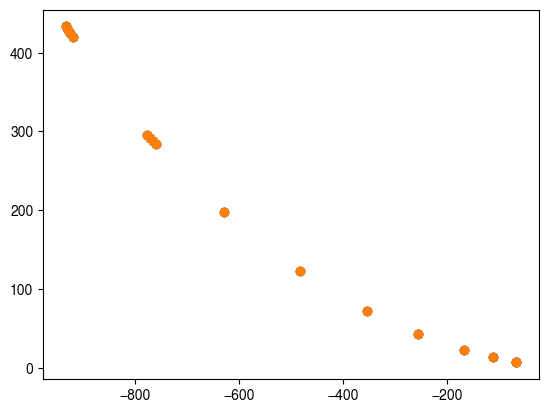

In [97]:
plt.scatter(this_track_hits.true_x, this_track_hits.true_y)
plt.scatter(majority_particle_hits.true_x, majority_particle_hits.true_y)

In [129]:
particles_all = pd.concat(particles_frames, ignore_index=True)
particles_out = Path(particles_out_dir) / (
    f"{dataset_name_dot}.truth.particles.events{start_event}-{end_event}.h5"
)
logger.info(f"Writing particles to: {particles_out} (rows={len(particles_all)})")
write_particles_with_selection(particles_all, str(particles_out), columns_keep=particles_columns_keep)

2025-09-24 06:23:41,989 - INFO - utils.config - Writing particles to: h5_testing/v4/full_pileup_pilot/ttbar/v2/hdf5/truth/particles/full_pileup_pilot.ttbar.v2.truth.particles.events0-9.h5 (rows=575394)


In [38]:
digihits_all = pd.concat(digihits_frames, ignore_index=True)
trkhits_out = Path(trkhits_out_dir) / (
    f"{dataset_name_dot}.reco.tracker_hits.events{start_event}-{end_event}.h5"
)
logger.info(f"Writing tracker hits to: {trkhits_out} (rows={len(digihits_all)})")
write_digihits_with_selection(digihits_all, str(trkhits_out), columns_keep=digihits_columns_keep)

2025-09-24 12:23:18,267 - INFO - utils.config - Writing tracker hits to: h5_testing/v4/full_pileup_pilot/ttbar/v2/hdf5/reco/tracker_hits/full_pileup_pilot.ttbar.v2.reco.tracker_hits.events0-9.h5 (rows=2639356)


In [131]:
tracks_all = pd.concat(tracks_frames, ignore_index=True)
tracks_out = Path(tracks_out_dir) / (
    f"{dataset_name_dot}.reco.tracks.events{start_event}-{end_event}.h5"
)
logger.info(f"Writing tracks to: {tracks_out} (rows={len(tracks_all)})")
write_tracks_with_selection(tracks_all, str(tracks_out), columns_keep=tracks_columns_keep)

2025-09-24 06:23:50,587 - INFO - utils.config - Writing tracks to: h5_testing/v4/full_pileup_pilot/ttbar/v2/hdf5/reco/tracks/full_pileup_pilot.ttbar.v2.reco.tracks.events0-9.h5 (rows=18638)
2025-09-24 06:23:50,666 - DEBUG - utils.track_utils - write_tracks_with_selection file=h5_testing/v4/full_pileup_pilot/ttbar/v2/hdf5/reco/tracks/full_pileup_pilot.ttbar.v2.reco.tracks.events0-9.h5 input_rows=18638 output_rows=18638 cols=['event_id', 'majority_particle_id', 'd0', 'z0', 'phi', 'theta', 'qop', 'hit_ids', 'track_id'] time=0.064s
2025-09-24 06:23:50,738 - DEBUG - h5py._conv - Creating converter from 5 to 3
2025-09-24 06:23:50,739 - DEBUG - utils.track_utils - Wrote event=0 tracks rows=1710 nnz=21338 time=0.070s
2025-09-24 06:23:50,746 - DEBUG - utils.track_utils - Wrote event=1 tracks rows=1824 nnz=22892 time=0.006s
2025-09-24 06:23:50,752 - DEBUG - utils.track_utils - Wrote event=2 tracks rows=1878 nnz=23418 time=0.006s
2025-09-24 06:23:50,759 - DEBUG - utils.track_utils - Wrote event=3

## Check track hits truth

In [ ]:
base_path = Path("/pscratch/sd/d/danieltm/ColliderML/simulation/full_pileup_pilot/ttbar/v2/runs/0")
edm4hep_path = base_path / "edm4hep.root"
simhits_path = base_path / "simhits.root"
measurements_path = base_path / "measurements.root"
particles_path = base_path / "particles.root"

# Load edm4hep event
event = EDM4hepEvent(str(edm4hep_path), event_index=0)
# Get tracker hits
tracker_hits = event.get_tracker_hits_df()
# Get particles
particles_df = event.get_particles_df()

In [ ]:
# Load simhits
simhits = load_root_file(str(simhits_path), event_id=0, included_columns=["event_id", "particle_id", "tx", "ty", "tz"])

In [ ]:
# Load measurements
measurements = load_root_file(str(measurements_path), event_id=0, included_columns=["event_id", "particle_id", "true_x", "true_y", "true_z"])

In [ ]:
# Load particles
particles = load_root_file(str(particles_path), event_id=0, included_columns=["event_id", "particle_id", "px", "py", "pz", "vx", "vy", "vz"])

In [ ]:
tracks_csv = pd.read_csv(base_path / "event000000000-tracks_ckf.csv")

In [ ]:
simhits.columns

Index(['event_id', 'particle_id', 'tx', 'ty', 'tz'], dtype='object')

In [ ]:
measurements.columns

Index(['true_x', 'true_y', 'true_z'], dtype='object')

In [ ]:
simhits

,event_id,particle_id,tx,ty,tz
entry,,,,,
0,0,193663580070084651,85.631775,3.625161,-1515.599976
1,0,761108337025679422,92.851669,-3.027657,-1515.599976
2,0,834744829761229871,66.317802,-7.857886,-1515.599976
3,0,261320928573718739,65.890350,-3.451361,-1515.599976
4,0,639627695319286115,92.188545,-4.542456,-1515.599976
...,...,...,...,...,...
240617,0,869194728082571378,421.881561,942.290344,3009.500000
240618,0,653021945968854818,306.645935,886.782227,3009.500000
240619,0,428042075716911252,331.738159,868.459473,3009.500000


In [ ]:
measurements

,true_x,true_y,true_z
entry,,,
0,85.631775,3.625161,-1515.599976
1,92.851669,-3.027657,-1515.599976
2,66.317802,-7.857886,-1515.599976
3,65.890350,-3.451361,-1515.599976
4,92.188545,-4.542456,-1515.599976
...,...,...,...
240609,421.881561,942.290344,3009.500000
240610,306.645935,886.782227,3009.500000
240611,331.738159,868.459473,3009.500000


In [ ]:
def convert_hit_ids(hit_ids_str: str) -> np.ndarray:
    hit_ids_str = hit_ids_str.strip('[]').split(',')
    result = np.array([int(x) for x in hit_ids_str if x.strip()], dtype=np.int32)
    return result

def get_majority_barcode(hit_ids, simhits_root_df):
    track_hits = simhits_root_df.iloc[convert_hit_ids(hit_ids)]
    # Get the majority barcode
    majority_barcode = track_hits.particle_id.mode()[0]
    return majority_barcode

def get_majority_count(hit_ids, simhits_root_df):
    track_hits = simhits_root_df.iloc[convert_hit_ids(hit_ids)]
    majority_count = track_hits.particle_id.value_counts().max()
    return majority_count

tracks_csv["majority_barcode"] = tracks_csv.Measurements_ID.apply(get_majority_barcode, simhits_root_df=simhits)
tracks_csv["majority_count"] = tracks_csv.Measurements_ID.apply(get_majority_count, simhits_root_df=simhits)
tracks_csv

,track_id,seed_id,particleId,nStates,nMajorityHits,nMeasurements,nOutliers,nHoles,nSharedHits,chi2,ndf,chi2/ndf,pT,eta,phi,truthMatchProbability,good/duplicate/fake,Measurements_ID,majority_barcode,majority_count
0,6527,554834,vp=138|vs=0|p=0|g=1|sp=389,26,10,10,0,2,0,18.61120,25,0.744449,2.01273,-2.559940,3.111560,1.000000,duplicate,"[37285,41817,22621,19462,12808,112083,108482,1...",621496748577194373,10
1,6498,550795,vp=139|vs=0|p=0|g=1|sp=1198,25,9,9,0,1,0,47.51460,22,2.159750,1.37208,-2.384340,3.137390,1.000000,duplicate,"[37199,41692,22619,19434,112067,108474,106200,...",626000348204565678,9
2,6497,550786,vp=139|vs=0|p=0|g=1|sp=1198,25,10,10,0,0,0,44.34840,25,1.773930,1.37233,-2.384430,3.137190,1.000000,good,"[37199,41692,22619,19434,16141,112067,108474,1...",626000348204565678,10
3,6494,550724,vp=156|vs=0|p=0|g=0|sp=176,21,6,7,1,2,0,7.79184,17,0.458343,2.38555,0.571278,3.104690,0.857143,good,"[37460,42011,55441,66754,123965,140597,164963,...",702561541869797552,5
4,6489,550303,vp=136|vs=0|p=0|g=1|sp=21,25,12,12,0,1,0,13.95670,24,0.581530,1.53996,0.396739,-3.128060,1.000000,duplicate,"[37742,42062,55478,66527,123979,140387,153598,...",612489549322453013,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3582,4077,350136,vp=194|vs=0|p=0|g=0|sp=86,30,10,12,0,3,0,25.05900,19,1.318900,1.74707,1.850270,0.904130,0.833333,duplicate,"[31578,133281,148481,171303,175269,178768,2343...",873698327709876310,2
3583,4078,350140,vp=194|vs=0|p=0|g=0|sp=86,30,10,12,0,3,0,25.29090,19,1.331100,1.74626,1.851190,0.904297,0.833333,duplicate,"[31663,133281,148481,171303,175269,178768,2343...",873698327709876310,2
3584,4079,350215,vp=160|vs=0|p=0|g=0|sp=116,21,8,8,1,0,0,17.34420,18,0.963565,1.16056,-1.738000,0.817770,1.000000,good,"[31413,49048,61669,133799,148825,117506,114158...",720575940379279476,7
3585,4080,350230,vp=178|vs=0|p=0|g=1|sp=114,26,13,13,0,0,0,25.83320,26,0.993586,1.10782,-1.432900,0.872837,1.000000,good,"[31647,49102,61743,62630,133435,148507,148247,...",801640733672013938,6


In [ ]:
tracks_csv[["nMajorityHits", "majority_count"]]

,nMajorityHits,majority_count
0,10,10
1,9,9
2,10,10
3,6,5
4,12,5
...,...,...
3582,10,2
3583,10,2
3584,8,7
3585,13,6


In [ ]:
tracks_csv["majority_barcode"] = tracks_csv.Measurements_ID.apply(get_majority_barcode, simhits_root_df=measurements)
tracks_csv["majority_count"] = tracks_csv.Measurements_ID.apply(get_majority_count, simhits_root_df=measurements)
tracks_csv

,track_id,seed_id,particleId,nStates,nMajorityHits,nMeasurements,nOutliers,nHoles,nSharedHits,chi2,ndf,chi2/ndf,pT,eta,phi,truthMatchProbability,good/duplicate/fake,Measurements_ID,majority_barcode,majority_count
0,6527,554834,vp=138|vs=0|p=0|g=1|sp=389,26,10,10,0,2,0,18.61120,25,0.744449,2.01273,-2.559940,3.111560,1.000000,duplicate,"[37285,41817,22621,19462,12808,112083,108482,1...",621496748577194373,10
1,6498,550795,vp=139|vs=0|p=0|g=1|sp=1198,25,9,9,0,1,0,47.51460,22,2.159750,1.37208,-2.384340,3.137390,1.000000,duplicate,"[37199,41692,22619,19434,112067,108474,106200,...",626000348204565678,9
2,6497,550786,vp=139|vs=0|p=0|g=1|sp=1198,25,10,10,0,0,0,44.34840,25,1.773930,1.37233,-2.384430,3.137190,1.000000,good,"[37199,41692,22619,19434,16141,112067,108474,1...",626000348204565678,10
3,6494,550724,vp=156|vs=0|p=0|g=0|sp=176,21,6,7,1,2,0,7.79184,17,0.458343,2.38555,0.571278,3.104690,0.857143,good,"[37460,42011,55441,66754,123965,140597,164963,...",702561541869797552,6
4,6489,550303,vp=136|vs=0|p=0|g=1|sp=21,25,12,12,0,1,0,13.95670,24,0.581530,1.53996,0.396739,-3.128060,1.000000,duplicate,"[37742,42062,55478,66527,123979,140387,153598,...",612489549322453013,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3582,4077,350136,vp=194|vs=0|p=0|g=0|sp=86,30,10,12,0,3,0,25.05900,19,1.318900,1.74707,1.850270,0.904130,0.833333,duplicate,"[31578,133281,148481,171303,175269,178768,2343...",873698327709876310,10
3583,4078,350140,vp=194|vs=0|p=0|g=0|sp=86,30,10,12,0,3,0,25.29090,19,1.331100,1.74626,1.851190,0.904297,0.833333,duplicate,"[31663,133281,148481,171303,175269,178768,2343...",873698327709876310,10
3584,4079,350215,vp=160|vs=0|p=0|g=0|sp=116,21,8,8,1,0,0,17.34420,18,0.963565,1.16056,-1.738000,0.817770,1.000000,good,"[31413,49048,61669,133799,148825,117506,114158...",720575940379279476,8
3585,4080,350230,vp=178|vs=0|p=0|g=1|sp=114,26,13,13,0,0,0,25.83320,26,0.993586,1.10782,-1.432900,0.872837,1.000000,good,"[31647,49102,61743,62630,133435,148507,148247,...",801640733672013938,13


In [ ]:
tracks_csv[["nMajorityHits", "majority_count"]]

,nMajorityHits,majority_count
0,10,10
1,9,9
2,10,10
3,6,6
4,12,12
...,...,...
3582,10,10
3583,10,10
3584,8,8
3585,13,13


In [ ]:
measurements["particle_id"] = measurements.merge(simhits[["particle_id", "tx", "ty", "tz"]], left_on=["true_x", "true_y", "true_z"], right_on=["tx", "ty", "tz"], how="left").particle_id

In [ ]:
# Merge all_particles_df with measurements value counts
all_particles_df["num_hits"] = all_particles_df.particle_barcode.map(measurements.particle_id.value_counts())

In [ ]:
all_particles_df.energy.describe()

count    840822.000000
mean          5.620686
std         113.113587
min           0.000002
25%           0.004093
50%           0.015933
75%           0.158609
max        7000.000000
Name: energy, dtype: float64

2025-09-12 04:41:50,457 - DEBUG - matplotlib.colorbar - locator: <matplotlib.ticker.AutoLocator object at 0x7fab258e1090>


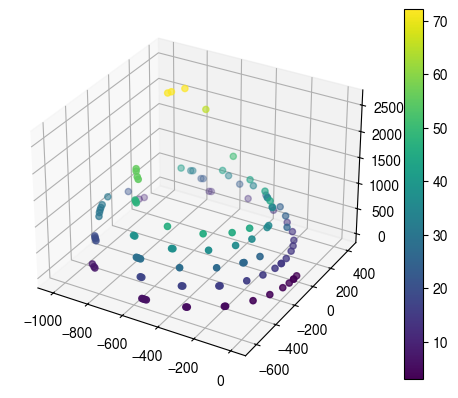

In [ ]:
multi_hits = tracker_hits[tracker_hits.particle_id == 34089]
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(multi_hits.x, multi_hits.y, multi_hits.z, c=multi_hits.time, cmap="viridis")
plt.colorbar(scatter)

## Testing h5 outputs

In [74]:
import pandas as pd
import h5py

def load_all_particles(h5_path, event_id=None):
    """
    Load particles data from HDF5 file.
    
    Args:
        h5_path: Path to HDF5 file
        event_id: Optional specific event ID to load. If None, loads all events.
    
    Returns:
        DataFrame with particles data
    """
    with h5py.File(h5_path, 'r') as f:
        frames = []
        
        if event_id is not None:
            # Direct access for single event
            ev_name = f'event_{event_id}'
            if ev_name in f['events']:
                arr = f['events'][ev_name]['particles'][:]
                df = pd.DataFrame(arr)
                df['event_id'] = event_id
                return df
            else:
                return pd.DataFrame()
        else:
            # Load all events
            for ev_name in f['events'].keys():
                ev_id = int(ev_name.split('_')[1])
                arr = f['events'][ev_name]['particles'][:]
                df = pd.DataFrame(arr)
                df['event_id'] = ev_id
                frames.append(df)
            return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

def load_all_digihits(h5_path, event_id=None):
    """
    Load digihits data from HDF5 file.
    
    Args:
        h5_path: Path to HDF5 file
        event_id: Optional specific event ID to load. If None, loads all events.
    
    Returns:
        DataFrame with digihits data
    """
    with h5py.File(h5_path, 'r') as f:
        frames = []
        
        if event_id is not None:
            # Direct access for single event
            ev_name = f'event_{event_id}'
            if ev_name in f['events']:
                arr = f['events'][ev_name]['measurements'][:]
                df = pd.DataFrame(arr)
                df['event_id'] = event_id
                return df
            else:
                return pd.DataFrame()
        else:
            # Load all events
            for ev_name in f['events'].keys():
                ev_id = int(ev_name.split('_')[1])
                arr = f['events'][ev_name]['measurements'][:]
                df = pd.DataFrame(arr)
                df['event_id'] = ev_id
                frames.append(df)
            return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

def load_all_tracks(h5_path, event_id=None):
    """
    Load tracks data from HDF5 file.
    
    Args:
        h5_path: Path to HDF5 file
        event_id: Optional specific event ID to load. If None, loads all events.
    
    Returns:
        Tuple of (tracks_df, hits_df) where hits_df contains track hit associations
    """
    with h5py.File(h5_path, 'r') as f:
        events = f.get('events')
        if events is None:
            return pd.DataFrame(), None
            
        if event_id is not None:
            # Direct access for single event
            ev_name = f'event_{event_id}'
            if ev_name in events:
                ev = events[ev_name]
                if 'tracks' not in ev:
                    return pd.DataFrame(), None
                    
                # Load tracks
                arr = ev['tracks'][:]
                tracks_df = pd.DataFrame(arr)
                tracks_df['event_id'] = event_id
                
                # Load hit associations
                if 'hit_ids_data' in ev and 'hit_ids_indptr' in ev:
                    data = ev['hit_ids_data'][:]
                    indptr = ev['hit_ids_indptr'][:]
                    if indptr is not None and len(indptr) >= 1:
                        hit_lists = [data[indptr[i]:indptr[i+1]] for i in range(len(indptr) - 1)]
                        hits_df = pd.DataFrame({
                            'event_id': event_id,
                            'track_id': tracks_df['track_id'].reset_index(drop=True),
                            'hit_ids': hit_lists
                        })
                        return tracks_df, hits_df
                    else:
                        return tracks_df, None
                else:
                    logger.warning(f"Missing hit_ids for event {ev_name}")
                    return tracks_df, None
            else:
                return pd.DataFrame(), None
        else:
            # Load all events
            frames = []
            hit_frames = []
            for ev_name in events.keys():
                ev = events[ev_name]
                try:
                    ev_id = int(ev_name.split('_')[1])
                except Exception:
                    continue
                # Tracks table
                if 'tracks' not in ev:
                    continue
                arr = ev['tracks'][:]
                df = pd.DataFrame(arr)
                df['event_id'] = ev_id
                frames.append(df)

                # Reconstruct hit_ids from CSR or fall back to legacy vlen
                if 'hit_ids_data' in ev and 'hit_ids_indptr' in ev:
                    data = ev['hit_ids_data'][:]
                    indptr = ev['hit_ids_indptr'][:]
                    if indptr is not None and len(indptr) >= 1:
                        hit_lists = [data[indptr[i]:indptr[i+1]] for i in range(len(indptr) - 1)]
                    else:
                        hit_lists = []
                    hit_df = pd.DataFrame({
                        'event_id': ev_id,
                        'track_id': df['track_id'].reset_index(drop=True),
                        'hit_ids': hit_lists
                    })
                    hit_frames.append(hit_df)
                else:
                    logger.warning(f"Missing hit_ids for event {ev_name}")
            tracks_df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
            if hit_frames:
                hits_df = pd.concat(hit_frames, ignore_index=True)
                return tracks_df, hits_df
            else:
                return tracks_df, None

In [75]:
particles_file = "/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/infrastructure/h5_testing/v4/full_pileup_pilot/ttbar/v2/hdf5/truth/particles/full_pileup_pilot.ttbar.v2.truth.particles.events0-9.h5"
digihits_file = "/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/infrastructure/h5_testing/v4/full_pileup_pilot/ttbar/v2/hdf5/reco/tracker_hits/full_pileup_pilot.ttbar.v2.reco.tracker_hits.events0-9.h5"
tracks_file = "/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/infrastructure/h5_testing/v4/full_pileup_pilot/ttbar/v2/hdf5/reco/tracks/full_pileup_pilot.ttbar.v2.reco.tracks.events0-9.h5"

In [ ]:
particles_file = "/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/infrastructure/h5_testing/v4/full_pileup_pilot/ttbar/v2/hdf5/truth/particles/full_pileup_pilot.ttbar.v2.truth.particles.events0-15.h5"
digihits_file = "/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/infrastructure/h5_testing/v4/full_pileup_pilot/ttbar/v2/hdf5/reco/tracker_hits/full_pileup_pilot.ttbar.v2.reco.tracker_hits.events0-15.h5"
tracks_file = "/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/infrastructure/h5_testing/v4/full_pileup_pilot/ttbar/v2/hdf5/reco/tracks/full_pileup_pilot.ttbar.v2.reco.tracks.events0-15.h5"

In [241]:
particles_file = "/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/infrastructure/h5_testing/v4/full_pileup_pilot/ttbar/v2/hdf5/truth/particles/full_pileup_pilot.ttbar.v2.truth.particles.events8-15.h5"
digihits_file = "/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/infrastructure/h5_testing/v4/full_pileup_pilot/ttbar/v2/hdf5/reco/tracker_hits/full_pileup_pilot.ttbar.v2.reco.tracker_hits.events8-15.h5"
tracks_file = "/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/infrastructure/h5_testing/v4/full_pileup_pilot/ttbar/v2/hdf5/reco/tracks/full_pileup_pilot.ttbar.v2.reco.tracks.events8-15.h5"

In [23]:
particles_file = "/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/infrastructure/h5_testing/v4/full_pileup_pilot/ttbar/v2/hdf5/truth/particles/full_pileup_pilot.ttbar.v2.truth.particles.events16-31.h5"
digihits_file = "/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/infrastructure/h5_testing/v4/full_pileup_pilot/ttbar/v2/hdf5/reco/tracker_hits/full_pileup_pilot.ttbar.v2.reco.tracker_hits.events16-31.h5"
tracks_file = "/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/infrastructure/h5_testing/v4/full_pileup_pilot/ttbar/v2/hdf5/reco/tracks/full_pileup_pilot.ttbar.v2.reco.tracks.events16-31.h5"

In [274]:
particles_file = "/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/infrastructure/h5_testing/v4/full_pileup_pilot/ttbar/v2/hdf5/truth/particles/full_pileup_pilot.ttbar.v2.truth.particles.events128-143.h5"
digihits_file = "/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/infrastructure/h5_testing/v4/full_pileup_pilot/ttbar/v2/hdf5/reco/tracker_hits/full_pileup_pilot.ttbar.v2.reco.tracker_hits.events128-143.h5"
tracks_file = "/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/infrastructure/h5_testing/v4/full_pileup_pilot/ttbar/v2/hdf5/reco/tracks/full_pileup_pilot.ttbar.v2.reco.tracks.events128-143.h5"

In [60]:
particles_file = "/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/infrastructure/h5_testing/v4/full_pileup_pilot/ttbar/v2/hdf5/truth/particles/full_pileup_pilot.ttbar.v2.truth.particles.events256-271.h5"
digihits_file = "/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/infrastructure/h5_testing/v4/full_pileup_pilot/ttbar/v2/hdf5/reco/tracker_hits/full_pileup_pilot.ttbar.v2.reco.tracker_hits.events256-271.h5"
tracks_file = "/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/infrastructure/h5_testing/v4/full_pileup_pilot/ttbar/v2/hdf5/reco/tracks/full_pileup_pilot.ttbar.v2.reco.tracks.events256-271.h5"

In [ ]:
particles_file = "/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/infrastructure/h5_testing/v4/full_pileup_pilot/ttbar/v2/hdf5/truth/particles/full_pileup_pilot.ttbar.v2.truth.particles.events128-255.h5"
digihits_file = "/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/infrastructure/h5_testing/v4/full_pileup_pilot/ttbar/v2/hdf5/reco/tracker_hits/full_pileup_pilot.ttbar.v2.reco.tracker_hits.events128-255.h5"
tracks_file = "/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/colliderml_dev/notebooks/infrastructure/h5_testing/v4/full_pileup_pilot/ttbar/v2/hdf5/reco/tracks/full_pileup_pilot.ttbar.v2.reco.tracks.events128-255.h5"

In [76]:
global_event_id = 9

In [77]:
particles_df = load_all_particles(particles_file, event_id = global_event_id)
digihits_df = load_all_digihits(digihits_file, event_id = global_event_id)
tracks_df, track_hits_df = load_all_tracks(tracks_file, event_id = global_event_id)

In [78]:
digihits_df

,x,y,z,time,particle_id,true_x,true_y,true_z,volume_id,layer_id,surface_id,cell_id,detector,event_id
0,59.015068,7.104694,-1515.599976,-1.148542,27190,58.993576,7.149262,-1515.599976,16,4,1,66320334951,1,9
1,53.486546,7.815578,-1515.599976,-1.149888,25911,53.480263,7.820048,-1515.599976,16,4,1,66102231143,1,9
2,91.354698,-5.717206,-1515.599976,10.271010,48067,91.367836,-5.699520,-1515.599976,16,4,1,1912602727,1,9
3,54.932846,-0.204066,-1515.599976,4.761894,348,54.921799,-0.204901,-1515.599976,16,4,1,67108967,1,9
4,95.859444,-10.609657,-1515.599976,8.775902,844092,95.856079,-10.626084,-1515.599976,16,4,1,3573547111,1,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278313,323.779755,936.174194,3009.500000,5.869032,528505,335.158447,965.065613,3009.500000,30,12,192,15899970015582,5,9
278314,408.292694,903.132080,3009.500000,9.372900,25100,394.327484,867.201721,3009.500000,30,12,192,906239185246,5,9
278315,382.473816,913.226501,3009.500000,1892.953491,694566,403.362732,966.639343,3009.387939,30,12,192,111670235486,5,9
278316,435.620636,892.447632,3009.500000,10.561299,77440,411.599091,830.854797,3009.500000,30,12,192,1748052775262,5,9


In [79]:
particles_df.shape

(100017, 17)

In [80]:
tracks_df

,majority_particle_id,d0,z0,phi,theta,qop,track_id,event_id
0,761169,0.282761,-181.161057,3.062308,2.280847,0.568151,1971,9
1,1757,0.220071,39.210133,3.066819,3.045950,-0.047052,1962,9
2,25251,-0.070745,-179.908020,3.045078,2.156133,-0.642216,1958,9
3,25314,-0.020010,-179.839493,3.084379,1.960520,0.443421,1957,9
4,92125,-0.171051,17.119959,3.106264,2.898688,0.208842,1956,9
...,...,...,...,...,...,...,...,...
1063,38313,0.055853,-54.327991,-0.057708,1.572298,-0.638424,1004,9
1064,72918,-0.069123,104.296318,-0.014211,2.501956,0.446152,1006,9
1065,86913,0.046857,55.788429,-0.078112,1.070089,-0.696426,1009,9
1066,86954,0.013680,55.687946,-0.080844,2.211093,-0.670188,1010,9


In [81]:
# Add number of hits of particle to tracks_df
tracks_df["num_particle_hits"] = tracks_df.merge(particles_df[["particle_id", "num_tracker_hits"]], left_on="majority_particle_id", right_on="particle_id", how="left").num_tracker_hits
tracks_df["num_track_hits"] = track_hits_df.hit_ids.apply(len)
tracks_df["hit_ids"] = track_hits_df.hit_ids

def get_num_shared_hits(track_row):
    track_hit_ids = track_row.hit_ids
    particle_hit_ids = digihits_df[digihits_df.particle_id == track_row.majority_particle_id].index.tolist()
    return len(set(track_hit_ids) & set(particle_hit_ids))

tracks_df["num_shared_hits"] = tracks_df.apply(get_num_shared_hits, axis=1)

In [82]:
tracks_df["efficiency"] = tracks_df["num_shared_hits"] / tracks_df["num_particle_hits"]
tracks_df["purity"] = tracks_df["num_shared_hits"] / tracks_df["num_track_hits"]

In [83]:
print(f"Efficiency: {tracks_df.efficiency.mean()}, Purity: {tracks_df.purity.mean()}")

Efficiency: 0.9422289509228071, Purity: 0.9691772054203351


In [143]:
for global_event_id in range(0, 10):
    particles_df = load_all_particles(particles_file, event_id = global_event_id)
    digihits_df = load_all_digihits(digihits_file, event_id = global_event_id)
    tracks_df, track_hits_df = load_all_tracks(tracks_file, event_id = global_event_id)
    tracks_df["num_particle_hits"] = tracks_df.merge(particles_df[["particle_id", "num_tracker_hits"]], left_on="majority_particle_id", right_on="particle_id", how="left").num_tracker_hits
    tracks_df["num_track_hits"] = track_hits_df.hit_ids.apply(len)
    tracks_df["hit_ids"] = track_hits_df.hit_ids
    tracks_df["num_shared_hits"] = tracks_df.apply(get_num_shared_hits, axis=1)
    tracks_df["completeness"] = tracks_df["num_shared_hits"] / tracks_df["num_particle_hits"]
    tracks_df["purity"] = tracks_df["num_shared_hits"] / tracks_df["num_track_hits"]
    print(f"Completeness: {tracks_df.completeness.mean()}, Purity: {tracks_df.purity.mean()}")


Completeness: 0.9465530295418678, Purity: 0.969453974817752
Completeness: 0.9424794132816426, Purity: 0.9670091257963743
Completeness: 0.9369805698244902, Purity: 0.9675394191204189
Completeness: 0.9420043207233924, Purity: 0.9680447437127282
Completeness: 0.9449978739444341, Purity: 0.9672868474298207
Completeness: 0.9468001337855267, Purity: 0.9661353037768304
Completeness: 0.9335801663651913, Purity: 0.9578598868499494
Completeness: 0.9395765137012085, Purity: 0.9661067886791957
Completeness: 0.9516165618303221, Purity: 0.976779718345848
Completeness: 0.942228950922807, Purity: 0.9691772054203351


In [82]:
track_hits_df.iloc[0]

event_id                                                    9
track_id                                                 1971
hit_ids     [48287, 48760, 63707, 76679, 142656, 161986, 1...
Name: 0, dtype: object

Text(0.5, 1.0, 'Track 0: Track hits vs True particle hits, track ID: 1971')

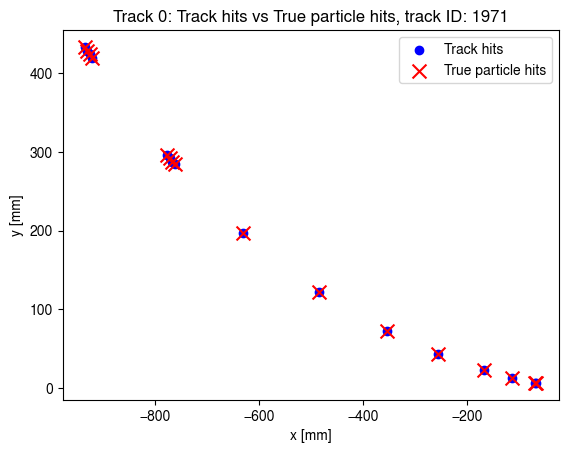

In [139]:
track_index = 0
track_hit_ids = track_hits_df.iloc[track_index].hit_ids

plt.scatter(digihits_df.x.iloc[track_hit_ids], digihits_df.y.iloc[track_hit_ids], marker='o', color="b", label="Track hits")

# Get the majority particle id for the track
track_majority_particle_id = tracks_df.iloc[track_index]['majority_particle_id']

# Get the hit ids for the majority particle id
majority_particle_hit_ids = digihits_df[digihits_df.particle_id == track_majority_particle_id].index.tolist()
plt.scatter(digihits_df.x.iloc[majority_particle_hit_ids], digihits_df.y.iloc[majority_particle_hit_ids], marker='x', color="red", s=100, label="True particle hits")

# Add legend
plt.legend()
plt.xlabel("x [mm]")
plt.ylabel("y [mm]")
plt.title(f"Track {track_index}: Track hits vs True particle hits, track ID: {tracks_df.track_id.iloc[track_index]}")

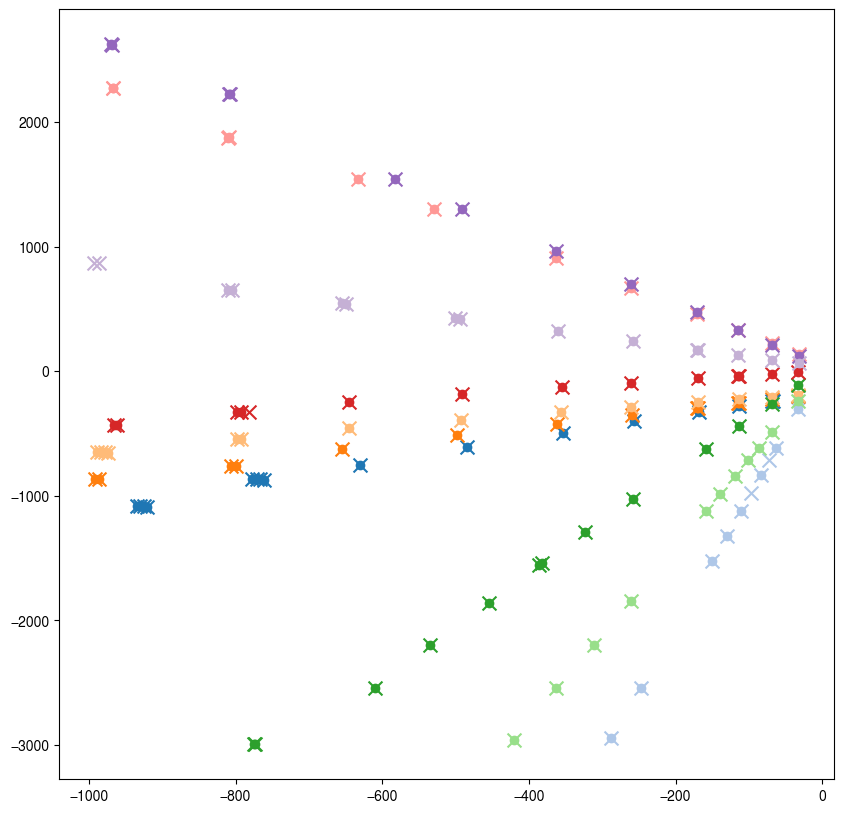

In [140]:
plt.figure(figsize=(10, 10))

num_tracks_to_sample = 10

# Define a list of colors to use for each track/particle pair
# Use tab20 colormap and cycle through it for more colors
cmap = plt.cm.tab20
colors = [cmap(i % 20) for i in range(num_tracks_to_sample)]

for i in range(num_tracks_to_sample):
    track_hit_ids = track_hits_df.iloc[i].hit_ids

    # Use the same color for both track hits and particle hits
    color = colors[i]
    
    plt.scatter(digihits_df.x.iloc[track_hit_ids], digihits_df.z.iloc[track_hit_ids], marker='o', color=color)

    # Get the majority particle id for the track
    track_majority_particle_id = tracks_df.iloc[i]['majority_particle_id']

    # Get the hit ids for the majority particle id
    majority_particle_hit_ids = digihits_df[digihits_df.particle_id == track_majority_particle_id].index.tolist()
    plt.scatter(digihits_df.x.iloc[majority_particle_hit_ids], digihits_df.z.iloc[majority_particle_hit_ids], marker='x', color=color, s=100)

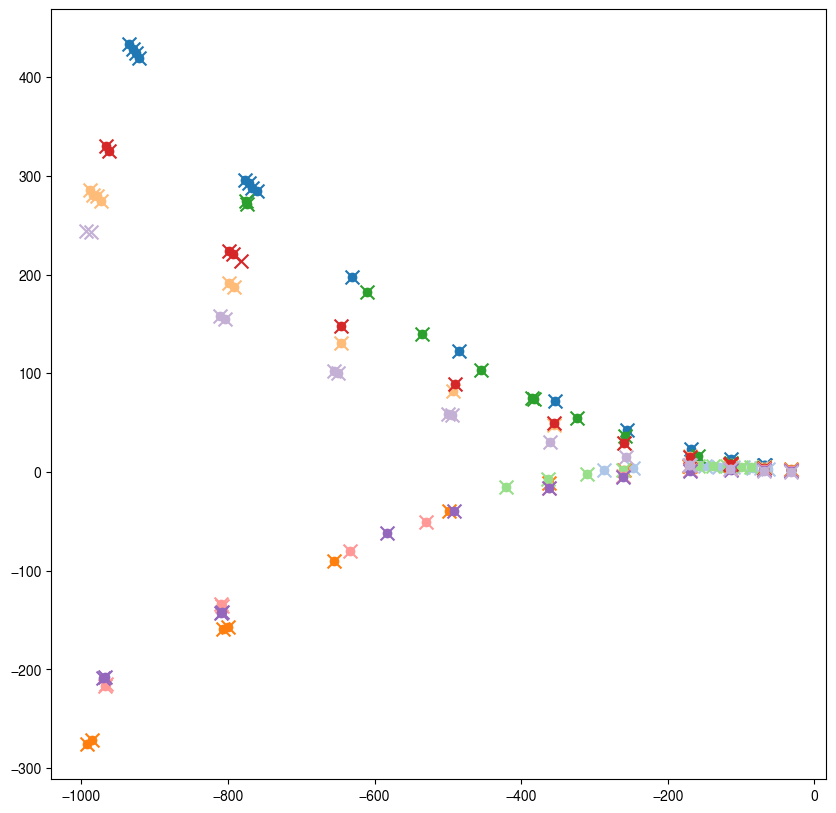

In [141]:
plt.figure(figsize=(10, 10))

num_tracks_to_sample = 10

# Define a list of colors to use for each track/particle pair
# Use tab20 colormap and cycle through it for more colors
cmap = plt.cm.tab20
colors = [cmap(i % 20) for i in range(num_tracks_to_sample)]

for i in range(num_tracks_to_sample):
    track_hit_ids = track_hits_df.iloc[i].hit_ids

    # Use the same color for both track hits and particle hits
    color = colors[i]
    
    plt.scatter(digihits_df.x.iloc[track_hit_ids], digihits_df.y.iloc[track_hit_ids], marker='o', color=color)

    # Get the majority particle id for the track
    track_majority_particle_id = tracks_df.iloc[i]['majority_particle_id']

    # Get the hit ids for the majority particle id
    majority_particle_hit_ids = digihits_df[digihits_df.particle_id == track_majority_particle_id].index.tolist()
    plt.scatter(digihits_df.x.iloc[majority_particle_hit_ids], digihits_df.y.iloc[majority_particle_hit_ids], marker='x', color=color, s=100)

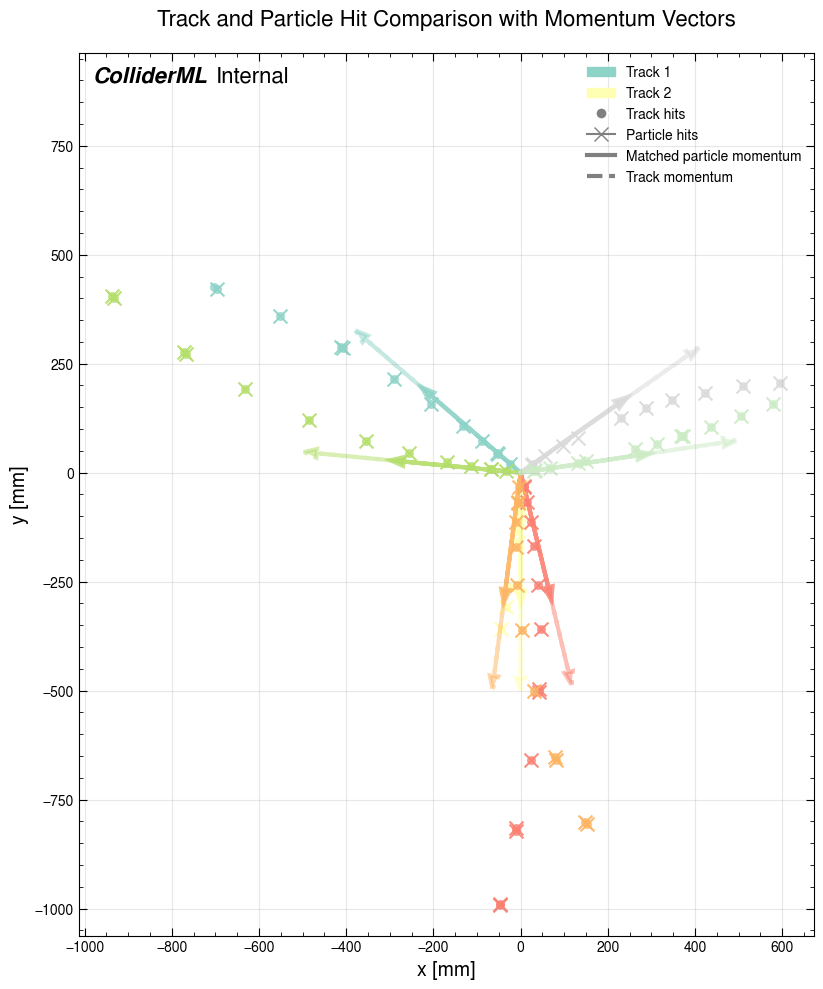

In [142]:
import matplotlib.patches as mpatches

plt.figure(figsize=(10, 10))
num_tracks_to_sample = 7

# Randomly sample track indices
track_indices = np.random.choice(len(tracks_df), size=min(num_tracks_to_sample, len(tracks_df)), replace=False)

# Use a pleasant colormap with more colors
cmap = plt.cm.Set3  # Set3 provides 12 distinct, pleasant colors
colors = [cmap(i / num_tracks_to_sample) for i in range(num_tracks_to_sample)]

legend_elements = []

for idx, track_idx in enumerate(track_indices):
    # Plot the track hits
    track_hit_ids = track_hits_df.iloc[track_idx].hit_ids
    track_scatter = plt.scatter(digihits_df.x.iloc[track_hit_ids], digihits_df.y.iloc[track_hit_ids], 
                               marker='o', color=colors[idx], s=30, alpha=0.7, 
                               label=f'Track {idx+1} hits')

    # Get the majority particle id for the track
    majority_particle_id = tracks_df.iloc[track_idx]['majority_particle_id']

    # Get the hit ids for the majority particle id
    majority_particle_hit_ids = digihits_df[digihits_df.particle_id == majority_particle_id].index.tolist()
    particle_scatter = plt.scatter(digihits_df.x.iloc[majority_particle_hit_ids], digihits_df.y.iloc[majority_particle_hit_ids], 
                                  marker='x', color=colors[idx], s=100, alpha=0.9,
                                  label=f'Particle {idx+1} hits')
    
    # Plot the phi vector of the particle as an arrow (solid arrow)
    particle_entry = particles_df[particles_df['particle_id'] == majority_particle_id].iloc[0]
    normalised_momentum_vector = particle_entry[['px', 'py']].values / np.linalg.norm(particle_entry[['px', 'py']].values)*300
    particle_arrow = plt.arrow(particle_entry['vx'], particle_entry['vy'], normalised_momentum_vector[0], normalised_momentum_vector[1], 
              color=colors[idx], head_width=20, head_length=30, length_includes_head=True, alpha=0.8, linewidth=3)
    phi = np.arctan2(particle_entry['py'], particle_entry['px'])

    # Plot the phi vector of the track (dashed arrow)
    track_entry = tracks_df.iloc[track_idx]
    phi = track_entry['phi']
    
    # Convert phi to px, py components (assuming unit momentum for visualization)
    track_px = np.cos(phi) * 500  # scale for visualization
    track_py = np.sin(phi) * 500
    
    # Plot from origin (assuming tracks start from origin for visualization)
    track_arrow = plt.arrow(0, 0, track_px, track_py, color=colors[idx], head_width=20, head_length=30, 
              length_includes_head=True, alpha=0.5, linewidth=3, linestyle='--')

# Create custom legend elements
legend_elements = [
    mpatches.Patch(color=colors[0], label='Track 1'),
    mpatches.Patch(color=colors[1], label='Track 2'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=8, label='Track hits'),
    plt.Line2D([0], [0], marker='x', color='gray', markerfacecolor='gray', markersize=10, label='Particle hits'),
    plt.Line2D([0], [0], color='gray', linewidth=3, label='Matched particle momentum'),
    plt.Line2D([0], [0], color='gray', linewidth=3, linestyle='--', label='Track momentum')
]

plt.legend(handles=legend_elements, loc='upper right', frameon=True, fancybox=True, shadow=True)

plt.xlabel('x [mm]', fontsize=14)
plt.ylabel('y [mm]', fontsize=14)
plt.title('Track and Particle Hit Comparison with Momentum Vectors', fontsize=16, pad=20)

# Add ATLAS label
atl.atlasify("Internal")

plt.grid(True, alpha=0.3)
plt.gca().set_aspect('equal', 'box')
plt.tight_layout()
plt.show()
